<a href="https://colab.research.google.com/github/RafaelaMlucca/AnaliseViolMulher/blob/main/notebooks/04_analise_descritiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Estatísticas Descritivas

**Projeto:** Assinaturas preditivas dos tipos de violência contra a mulher  
**Autora:** Rafaela Lucca



## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pysus geopandas --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.7/385.7 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import gc
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

DRIVE = Path('/content/drive/MyDrive/projeto_violencia_mulher')
DESC = DRIVE / 'Descritiva'              # pasta isolada da modelagem
PARTES_DESC = DESC / 'partes'
DESC.mkdir(parents=True, exist_ok=True)
PARTES_DESC.mkdir(parents=True, exist_ok=True)

print(f'Pasta da descritiva: {DESC}')

Pasta da descritiva: /content/drive/MyDrive/projeto_violencia_mulher/Descritiva


---

## 2. Ingestão própria — colunas para descritiva


In [7]:
COLS_DESC = [
    # Identificação
    'NU_ANO', 'SG_UF_NOT', 'TPUNINOT', 'DT_NOTIFIC', 'DT_OCOR',

    # Vítima
    'CS_SEXO', 'NU_IDADE_N', 'ANO_NASC', 'CS_RACA', 'CS_ESCOL_N', 'CS_GESTANT',
    'ORIENT_SEX', 'IDENT_GEN', 'SIT_CONJUG',
    'DEF_TRANS', 'DEF_FISICA', 'DEF_MENTAL',

    # Pseudoidentificadores disponíveis (para potencial linkagem)
    'ID_MN_RESI', 'NDUPLIC',

    # Ocorrência
    'LOCAL_OCOR', 'HORA_OCOR', 'OUT_VEZES', 'LES_AUTOP', 'CICL_VID',

    # Tipos de violência
    'VIOL_FISIC', 'VIOL_PSICO', 'VIOL_TORT', 'VIOL_SEXU',
    'VIOL_TRAF', 'VIOL_FINAN', 'VIOL_NEGLI', 'VIOL_INFAN',
    'VIOL_LEGAL', 'VIOL_OUTR',

    # Meios de agressão
    'AG_FORCA', 'AG_ENFOR', 'AG_OBJETO', 'AG_CORTE',
    'AG_QUENTE', 'AG_ENVEN', 'AG_FOGO', 'AG_AMEACA', 'AG_OUTROS',

    # Autor
    'AUTOR_SEXO', 'AUTOR_ALCO',

    # Relação com agressor
    'REL_PAI', 'REL_MAE', 'REL_CONJ', 'REL_EXCON', 'REL_NAMO',
    'REL_EXNAM', 'REL_FILHO', 'REL_IRMAO',
    'REL_CONHEC', 'REL_DESCO', 'REL_CUIDA', 'REL_PATRAO',

    # Gravidade e desfecho
    'LESAO_NAT', 'EVOLUCAO', 'CIRC_LESAO',
]

In [5]:
# Baixa via pysus (provavelmente já está em cache local)
from pysus import SINAN

ANOS = list(range(2020, 2025))

sinan = SINAN().load()
files = sinan.get_files(dis_code='VIOL', year=ANOS)
sinan.download(files)

paths = sorted(glob.glob('/root/pysus/VIOLBR*.parquet'))
paths = [p for p in paths if any(f'VIOLBR{a%100:02d}' in p for a in ANOS)]
print(f'{len(paths)} arquivos disponíveis')

VIOLBR24.parquet: 100%|██████████| 1.77M/1.77M [02:29<00:00, 11.8kB/s]

5 arquivos disponíveis


In [8]:
# Loop de processamento — salva em PARTES_DESC
for p in paths:
    nome = Path(p).stem
    saida = PARTES_DESC / f'{nome}_desc.parquet'

    if saida.exists():
        print(f'{nome}: já existe, pulando')
        continue

    df_ano = pd.read_parquet(p, columns=COLS_DESC)
    n_total = len(df_ano)

    df_ano = df_ano[df_ano['CS_SEXO'] == 'F'].reset_index(drop=True)
    n_mulher = len(df_ano)

    df_ano.to_parquet(saida, index=False)
    print(f'{nome}: {n_total:>7,} -> {n_mulher:>7,} mulheres')

    del df_ano
    gc.collect()

print('\nProcessamento concluído.')

VIOLBR20: 326,503 -> 233,072 mulheres
VIOLBR21: 373,262 -> 268,884 mulheres
VIOLBR22: 442,680 -> 318,137 mulheres
VIOLBR23: 588,388 -> 419,967 mulheres
VIOLBR24: 616,548 -> 437,828 mulheres

Processamento concluído.


In [9]:
# Concatena
partes = sorted(PARTES_DESC.glob('*_desc.parquet'))
print(f'Concatenando {len(partes)} partes...')

dfs = [pd.read_parquet(p) for p in partes]
df = pd.concat(dfs, ignore_index=True)
del dfs
gc.collect()

print(f'Base descritiva: {df.shape}')

Concatenando 5 partes...
Base descritiva: (1677888, 60)


---

## 3. Limpeza mínima — replicar o que fizemos no notebook 03

In [10]:
def idade_em_anos(codigo):
    if pd.isna(codigo): return np.nan
    s = str(codigo).zfill(4)
    if s[0] == '4': return int(s[1:])
    if s[0] in ('1','2','3'): return 0
    return np.nan

# Idade
df['IDADE'] = df['NU_IDADE_N'].apply(idade_em_anos)
df.loc[df['IDADE'] > 110, 'IDADE'] = np.nan

# Strings vazias -> NaN
df = df.replace({'': np.nan})

# Duplicatas
df = df.drop_duplicates().reset_index(drop=True)

# Alvos
for col in ['VIOL_FISIC', 'VIOL_PSICO', 'VIOL_SEXU']:
    novo = 'y_' + col.replace('VIOL_', '').lower()
    df[novo] = df[col].map({'1': 1, '2': 0})

# Salva snapshot da base descritiva
df.to_parquet(DESC / 'viol_descritiva.parquet', index=False)
print(f'Salvo: {DESC / "viol_descritiva.parquet"}')
print(f'Shape: {df.shape}')

Salvo: /content/drive/MyDrive/projeto_violencia_mulher/Descritiva/viol_descritiva.parquet
Shape: (1677301, 64)


---

## 4. Pseudoidentificadores — investigar mascaramento

Antes de qualquer análise de revitimização, **olhar como os identificadores aparecem na base**.

In [11]:
# Amostra de pseudoidentificadores
print('Amostra dos campos disponíveis:\n')
df[['ANO_NASC', 'ID_MN_RESI', 'NDUPLIC', 'IDADE']].head(20)

Amostra dos campos disponíveis:



,ANO_NASC,ID_MN_RESI,NDUPLIC,IDADE
0,1965,280230,,55.0
1,1983,316740,,36.0
2,1985,280060,,35.0
3,1964,280030,,56.0
4,1990,280650,,30.0
5,1984,280250,,36.0
6,2000,280330,,20.0
7,1960,316740,,59.0
8,1995,280660,,25.0
9,1993,280480,,27.0


---

## 5. Dicionários de rótulos

In [16]:
MAP_RACA = {'1': 'Branca', '2': 'Preta', '3': 'Amarela',
            '4': 'Parda', '5': 'Indígena', '9': 'Ignorado'}

MAP_ESCOL = {'00': 'Analfabeto', '01': '1ª-4ª inc.', '02': '4ª completa',
             '03': '5ª-8ª inc.', '04': 'EF completo', '05': 'EM incompleto',
             '06': 'EM completo', '07': 'Sup. inc.', '08': 'Sup. completo',
             '09': 'Ignorado', '10': 'Não se aplica'}

MAP_GEST = {'1': '1º Trim', '2': '2º Trim', '3': '3º Trim',
            '4': 'Idade gest. ign.', '5': 'Não', '6': 'Não se aplica',
            '9': 'Ignorado'}

MAP_LOCAL = {'01': 'Residência', '02': 'Hab. coletiva', '03': 'Escola',
             '04': 'Local esportivo', '05': 'Bar', '06': 'Via pública',
             '07': 'Comércio', '08': 'Indústria', '09': 'Outro',
             '99': 'Ignorado'}

MAP_AUTOR_SEXO = {'1': 'Masculino', '2': 'Feminino',
                  '3': 'Ambos os sexos', '9': 'Ignorado'}

MAP_CICLO = {'1': 'Criança', '2': 'Adolescente', '3': 'Jovem',
             '4': 'Adulto', '5': 'Idoso', '9': 'Ignorado'}

MAP_SIM_NAO = {'1': 'Sim', '2': 'Não', '9': 'Ignorado'}

MAP_EVOLUCAO = {'1': 'Alta', '2': 'Evasão/Fuga', '3': 'Óbito por viol.',
                '4': 'Óbito outra causa', '9': 'Ignorada'}

# Faixa etária
def faixa_etaria(idade):
    if pd.isna(idade): return 'Sem info'
    if idade < 10:    return '0-9 (criança)'
    if idade < 15:    return '10-14 (adol.)'
    if idade < 20:    return '15-19 (adol.)'
    if idade < 30:    return '20-29 (jovem)'
    if idade < 45:    return '30-44 (adulta)'
    if idade < 60:    return '45-59 (adulta)'
    return '60+ (idosa)'

df['FAIXA_ETARIA'] = df['IDADE'].apply(faixa_etaria)
df['RACA']  = df['CS_RACA'].map(MAP_RACA).fillna('Não informado')
df['ESCOL'] = df['CS_ESCOL_N'].map(MAP_ESCOL).fillna('Não informado')
df['LOCAL'] = df['LOCAL_OCOR'].map(MAP_LOCAL).fillna('Não informado')

print('Dicionários e variáveis derivadas criadas.')

Dicionários e variáveis derivadas criadas.


---

# Bloco 1 — Perfil sociodemográfico das vítimas

## 1.1 — Idade

In [17]:
idade = df['IDADE'].dropna()

print('IDADE — medidas resumidas')
print(f'  n              = {len(idade):,}')
print(f'  Média          = {idade.mean():.2f}')
print(f'  Mediana        = {idade.median():.0f}')
print(f'  Moda           = {idade.mode().iloc[0]:.0f}')
print(f'  Desvio-padrão  = {idade.std():.2f}')
print(f'  Variância      = {idade.var():.2f}')
print(f'  Q1 / Q3        = {idade.quantile(0.25):.0f} / {idade.quantile(0.75):.0f}')
print(f'  IQR            = {idade.quantile(0.75) - idade.quantile(0.25):.0f}')
print(f'  Min / Max      = {idade.min():.0f} / {idade.max():.0f}')
print(f'  Assimetria     = {stats.skew(idade):.3f}')
print(f'  Curtose        = {stats.kurtosis(idade):.3f}')

IDADE — medidas resumidas
  n              = 1,673,993
  Média          = 28.33
  Mediana        = 26
  Moda           = 13
  Desvio-padrão  = 17.12
  Variância      = 292.97
  Q1 / Q3        = 16 / 38
  IQR            = 22
  Min / Max      = 0 / 110
  Assimetria     = 0.822
  Curtose        = 0.769


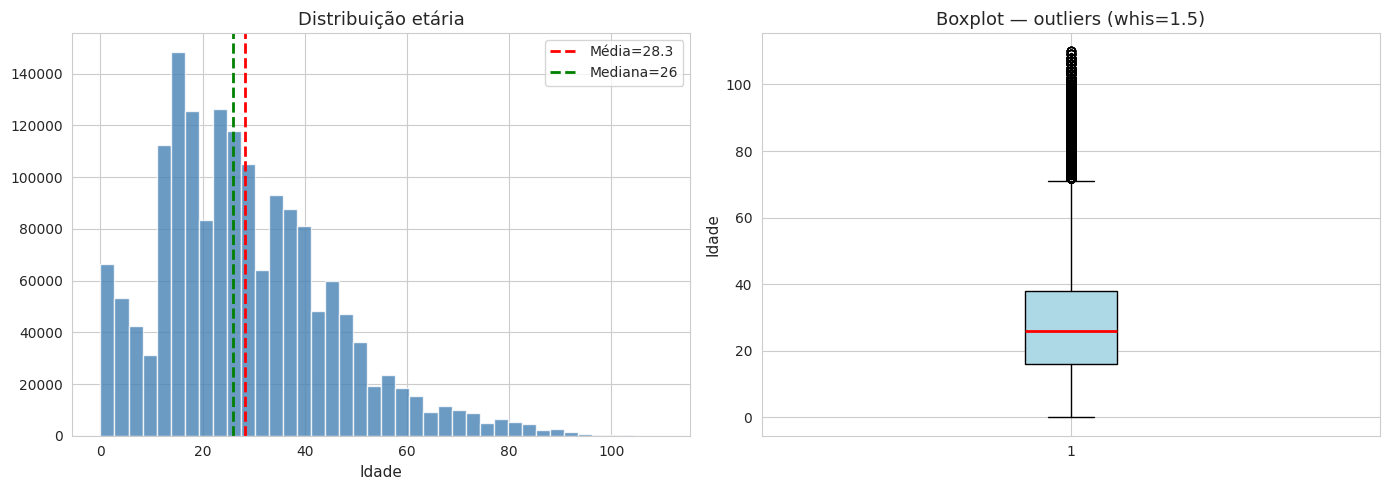

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(idade, bins=40, edgecolor='white', alpha=0.8, color='steelblue')
axes[0].axvline(idade.mean(),   color='red',   ls='--', lw=2, label=f'Média={idade.mean():.1f}')
axes[0].axvline(idade.median(), color='green', ls='--', lw=2, label=f'Mediana={idade.median():.0f}')
axes[0].set_title('Distribuição etária')
axes[0].set_xlabel('Idade'); axes[0].legend()

axes[1].boxplot(idade, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot — outliers (whis=1.5)')
axes[1].set_ylabel('Idade')

plt.tight_layout(); plt.show()

## 1.2 — Raça/cor com comparação ao Censo

In [19]:
pop_brasil = pd.Series({
    'Parda': 45.3, 'Branca': 43.5, 'Preta': 10.2,
    'Amarela': 0.4, 'Indígena': 0.6
})

validos = df[df['RACA'].isin(pop_brasil.index)]
viol_dist = validos['RACA'].value_counts(normalize=True) * 100

comp = pd.DataFrame({
    'População BR (%)': pop_brasil,
    'Vítimas SINAN (%)': viol_dist.reindex(pop_brasil.index)
})
comp['Diferença (pp)'] = (comp['Vítimas SINAN (%)'] - comp['População BR (%)']).round(1)
print('Composição racial: pop. BR vs. vítimas SINAN\n')
print(comp.round(1))

Composição racial: pop. BR vs. vítimas SINAN

          População BR (%)  Vítimas SINAN (%)  Diferença (pp)
Parda                 45.3               47.5             2.2
Branca                43.5               41.1            -2.4
Preta                 10.2                9.5            -0.7
Amarela                0.4                1.0             0.6
Indígena               0.6                0.9             0.3


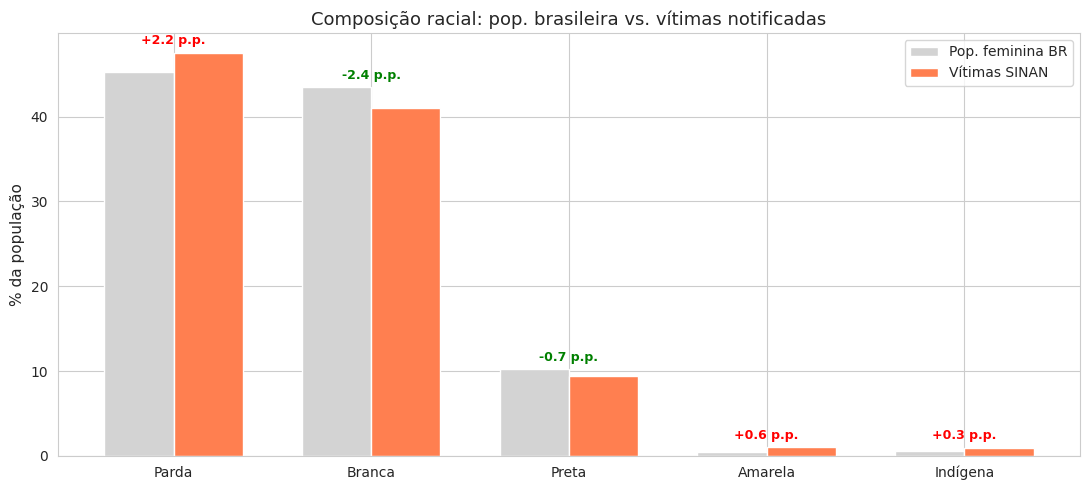

In [20]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comp))
w = 0.35
ax.bar(x - w/2, comp['População BR (%)'], w, label='Pop. feminina BR', color='lightgray')
ax.bar(x + w/2, comp['Vítimas SINAN (%)'], w, label='Vítimas SINAN', color='coral')
ax.set_xticks(x); ax.set_xticklabels(comp.index)
ax.set_ylabel('% da população')
ax.set_title('Composição racial: pop. brasileira vs. vítimas notificadas')
ax.legend()

for i, (idx, row) in enumerate(comp.iterrows()):
    diff = row['Diferença (pp)']
    cor = 'red' if diff > 0 else 'green'
    ax.text(i, max(row['População BR (%)'], row['Vítimas SINAN (%)']) + 1,
            f'{diff:+.1f} p.p.', ha='center', fontsize=9, color=cor, fontweight='bold')

plt.tight_layout(); plt.show()

## 1.3 — Escolaridade

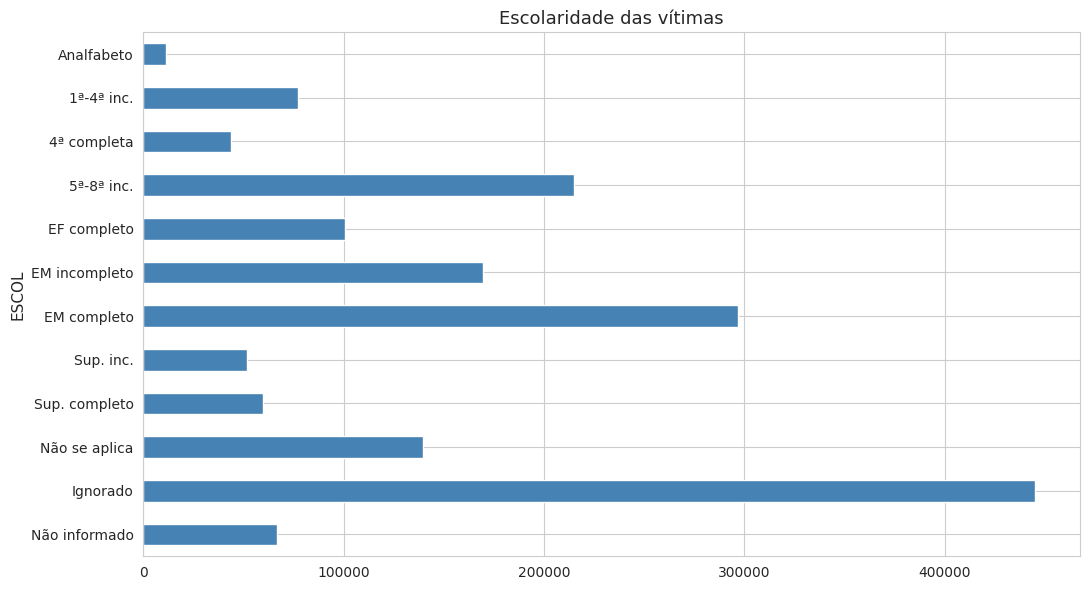

In [21]:
ordem_escol = ['Analfabeto', '1ª-4ª inc.', '4ª completa', '5ª-8ª inc.',
               'EF completo', 'EM incompleto', 'EM completo',
               'Sup. inc.', 'Sup. completo', 'Não se aplica',
               'Ignorado', 'Não informado']
escol_dist = df['ESCOL'].value_counts().reindex(ordem_escol).dropna()

fig, ax = plt.subplots(figsize=(11, 6))
escol_dist.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Escolaridade das vítimas')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

---

# Bloco 2 — Quem é o agressor

In [40]:
# População adulta brasileira por sexo (Censo 2022, em milhares)
# Pessoas 15+ anos, que é a faixa mais provável de cometer agressão
POP_ADULTA = {
    'Masculino': 81_500,   # ~81,5 milhões de homens 15+
    'Feminino':  87_300,   # ~87,3 milhões de mulheres 15+
}
# Fonte aproximada: IBGE Censo 2022

print('Taxa de agressão por 100 mil pessoas daquele sexo (2020-2024):\n')

for tipo, nome in [('y_fisic', 'FÍSICA'),
                    ('y_psico', 'PSICOLÓGICA'),
                    ('y_sexu',  'SEXUAL')]:
    sub = df[df[tipo] == 1]

    # Conta agressores por sexo (apenas casos identificados)
    cont = sub['AUTOR_SEXO'].map(MAP_AUTOR_SEXO).value_counts()

    # Taxa = agressões / pop daquele sexo / 5 anos * 100k
    taxas = {}
    for sexo, pop in POP_ADULTA.items():
        if sexo in cont.index:
            taxas[sexo] = cont[sexo] / pop / 5 * 100

    print(f'=== {nome} ===')
    for sexo, t in taxas.items():
        print(f'  {sexo:11s}: {t:>6.1f} agressores por 100k {sexo.lower()}s/ano')

    # Razão de chances aproximada
    if 'Masculino' in taxas and 'Feminino' in taxas and taxas['Feminino'] > 0:
        razao = taxas['Masculino'] / taxas['Feminino']
        print(f'  -> Homens são {razao:.1f}x mais propensos a serem agressores')
    print()

Taxa de agressão por 100 mil pessoas daquele sexo (2020-2024):

=== FÍSICA ===
  Masculino  :  127.9 agressores por 100k masculinos/ano
  Feminino   :   48.6 agressores por 100k femininos/ano
  -> Homens são 2.6x mais propensos a serem agressores

=== PSICOLÓGICA ===
  Masculino  :   75.3 agressores por 100k masculinos/ano
  Feminino   :   11.3 agressores por 100k femininos/ano
  -> Homens são 6.7x mais propensos a serem agressores

=== SEXUAL ===
  Masculino  :   59.9 agressores por 100k masculinos/ano
  Feminino   :    1.6 agressores por 100k femininos/ano
  -> Homens são 37.6x mais propensos a serem agressores



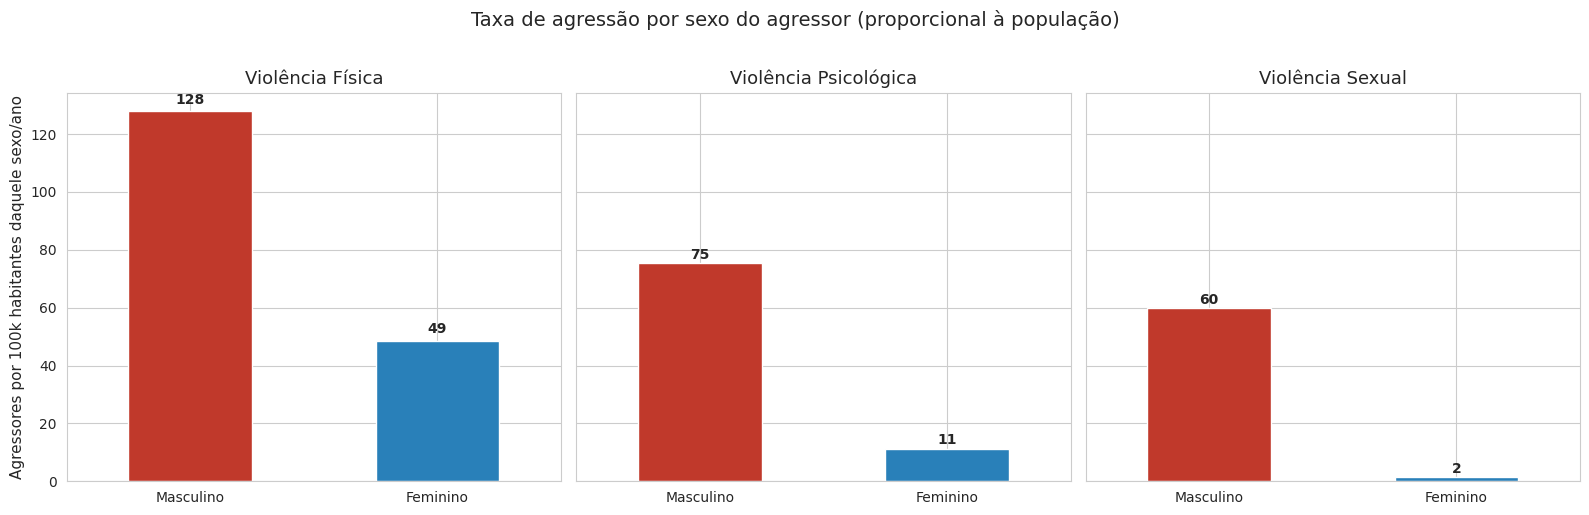

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, tipo, nome in zip(axes, ['y_fisic','y_psico','y_sexu'],
                           ['Física','Psicológica','Sexual']):
    sub = df[df[tipo] == 1]
    cont = sub['AUTOR_SEXO'].map(MAP_AUTOR_SEXO).value_counts()

    taxas = {}
    for sexo, pop in POP_ADULTA.items():
        if sexo in cont.index:
            taxas[sexo] = cont[sexo] / pop / 5 * 100

    s = pd.Series(taxas).sort_values(ascending=False)
    s.plot(kind='bar', ax=ax, color=['#c0392b', '#2980b9'])
    ax.set_title(f'Violência {nome}')
    ax.set_ylabel('Agressores por 100k habitantes daquele sexo/ano')
    ax.tick_params(axis='x', rotation=0)

    for i, v in enumerate(s):
        ax.text(i, v + s.max()*0.02, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Taxa de agressão por sexo do agressor (proporcional à população)',
              y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

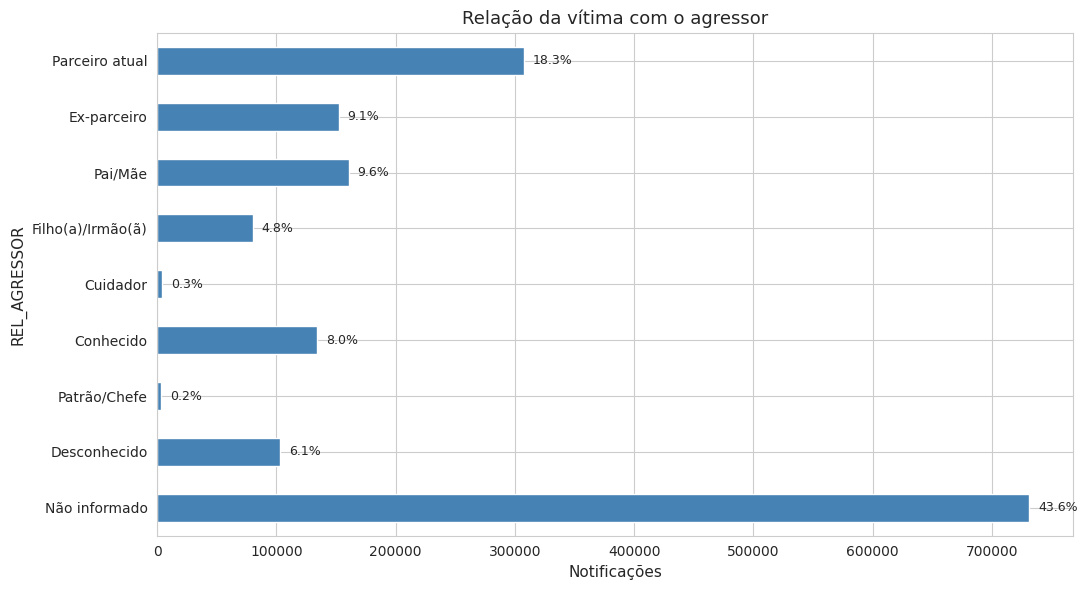

In [24]:
# Relação com agressor — categorias hierárquicas
def classificar_agressor(row):
    if row.get('REL_CONJ') == '1' or row.get('REL_NAMO') == '1':
        return 'Parceiro atual'
    if row.get('REL_EXCON') == '1' or row.get('REL_EXNAM') == '1':
        return 'Ex-parceiro'
    if row.get('REL_PAI') == '1' or row.get('REL_MAE') == '1':
        return 'Pai/Mãe'
    if row.get('REL_FILHO') == '1' or row.get('REL_IRMAO') == '1':
        return 'Filho(a)/Irmão(ã)'
    if row.get('REL_CUIDA') == '1': return 'Cuidador'
    if row.get('REL_CONHEC') == '1': return 'Conhecido'
    if row.get('REL_PATRAO') == '1': return 'Patrão/Chefe'
    if row.get('REL_DESCO') == '1': return 'Desconhecido'
    return 'Não informado'

df['REL_AGRESSOR'] = df.apply(classificar_agressor, axis=1)

ordem = ['Parceiro atual','Ex-parceiro','Pai/Mãe','Filho(a)/Irmão(ã)',
         'Cuidador','Conhecido','Patrão/Chefe','Desconhecido','Não informado']
rel_dist = df['REL_AGRESSOR'].value_counts().reindex(ordem)
prop = (rel_dist / rel_dist.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(11, 6))
rel_dist.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Relação da vítima com o agressor')
ax.set_xlabel('Notificações')
ax.invert_yaxis()
for i, (cat, n) in enumerate(rel_dist.items()):
    ax.text(n + rel_dist.max()*0.01, i, f'{prop[cat]:.1f}%', va='center', fontsize=9)
plt.tight_layout(); plt.show()

Coluna usada: CICL_VID
AVISO: CICL_VID_AUTOR não existe; analisando o ciclo de vida da VÍTIMA.

CICL_VID
Adulto         889911
Ignorado       250165
Adolescente    234435
Jovem          232574
Idoso           48327
Criança         15239
NaN              6650
Name: count, dtype: int64


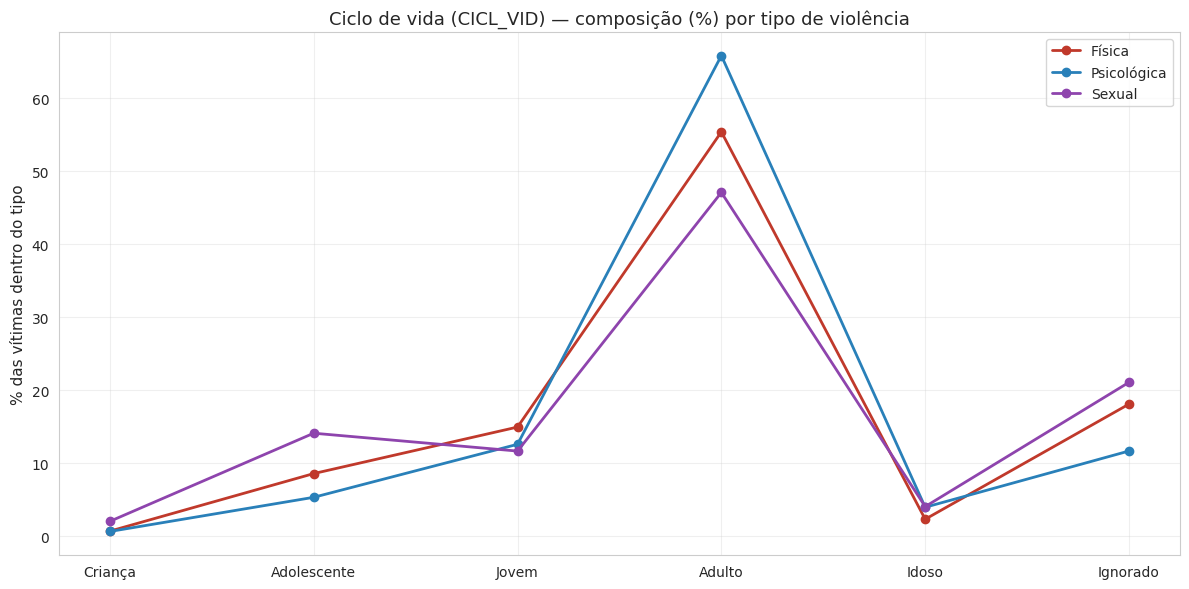

In [79]:
# ============================================================
# 4.1 — Ciclo de vida do agressor
# ============================================================
# Tenta CICL_VID_AUTOR; se não existir, usa CICL_VID (vítima) como fallback
col_ciclo = 'CICL_VID_AUTOR' if 'CICL_VID_AUTOR' in df.columns else 'CICL_VID'
print(f'Coluna usada: {col_ciclo}')

if col_ciclo == 'CICL_VID':
    print('AVISO: CICL_VID_AUTOR não existe; analisando o ciclo de vida da VÍTIMA.\n')

ciclo_dist = df[col_ciclo].map(MAP_CICLO).value_counts(dropna=False)
print(ciclo_dist)

# Por tipo de violência
ordem_ciclo = ['Criança', 'Adolescente', 'Jovem', 'Adulto', 'Idoso', 'Ignorado']
fig, ax = plt.subplots(figsize=(12, 6))
for tipo, nome, cor in [('y_fisic', 'Física', '#c0392b'),
                         ('y_psico', 'Psicológica', '#2980b9'),
                         ('y_sexu', 'Sexual', '#8e44ad')]:
    sub = df[df[tipo] == 1]
    s = sub[col_ciclo].map(MAP_CICLO).value_counts(normalize=True) * 100
    s = s.reindex(ordem_ciclo).dropna()
    ax.plot(s.index, s.values, marker='o', linewidth=2, label=nome, color=cor)

ax.set_title(f'Ciclo de vida ({col_ciclo}) — composição (%) por tipo de violência')
ax.set_ylabel('% das vítimas dentro do tipo')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

% de casos com álcool no agressor, por tipo de relação:

REL_AGRESSOR
Cuidador              9.1
Patrão/Chefe         13.8
Pai/Mãe              22.4
Filho(a)/Irmão(ã)    35.6
Conhecido            39.0
Desconhecido         48.6
Ex-parceiro          48.6
Parceiro atual       54.5
Name: ALCOOL, dtype: float64


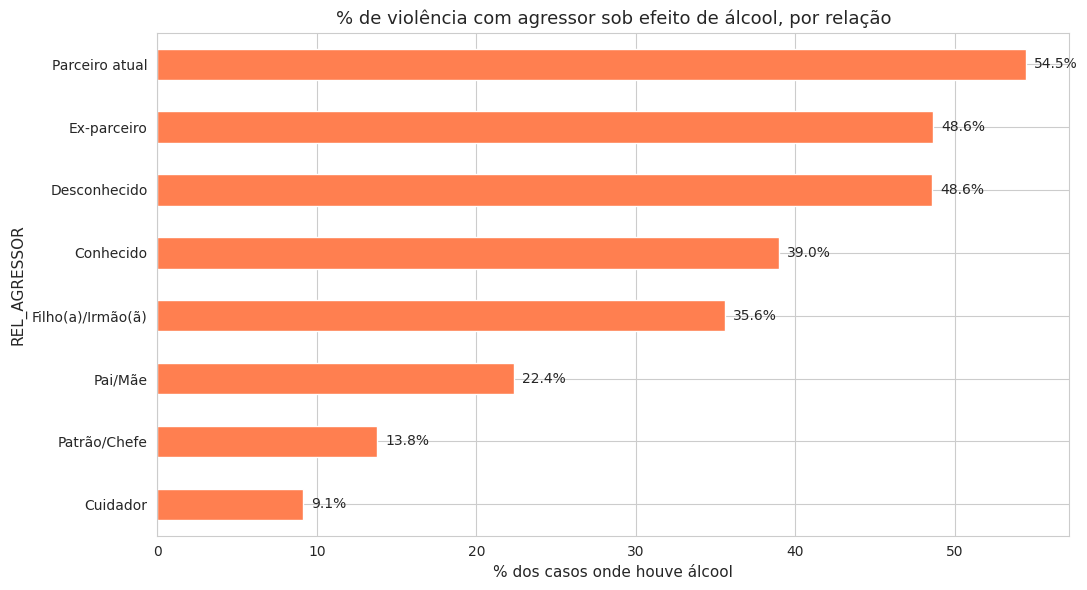

In [80]:
# ============================================================
# 4.3 — Álcool por tipo de relação com agressor
# ============================================================
sub = df[
    df['AUTOR_ALCO'].isin(['1', '2']) &
    df['REL_AGRESSOR'].isin(ordem_rel[:-1])  # tira "Não informado"
].copy()
sub['ALCOOL'] = sub['AUTOR_ALCO'].map({'1': 'Sim', '2': 'Não'})

# % com álcool dentro de cada relação
tab_alco_rel = (
    sub.groupby('REL_AGRESSOR')['ALCOOL']
       .apply(lambda x: (x == 'Sim').mean() * 100)
       .reindex(ordem_rel[:-1])
       .sort_values(ascending=True)
)

print('% de casos com álcool no agressor, por tipo de relação:\n')
print(tab_alco_rel.round(1))

fig, ax = plt.subplots(figsize=(11, 6))
tab_alco_rel.plot(kind='barh', ax=ax, color='coral')
ax.set_title('% de violência com agressor sob efeito de álcool, por relação')
ax.set_xlabel('% dos casos onde houve álcool')

for i, v in enumerate(tab_alco_rel):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

---

# Bloco 3 — Geografia (mapas coropléticos)

In [25]:
POP_FEM_UF = {
    'AC': 435, 'AL': 1659, 'AP': 376, 'AM': 2056, 'BA': 7505,
    'CE': 4720, 'DF': 1499, 'ES': 2076, 'GO': 3565, 'MA': 3534,
    'MG': 10662, 'MS': 1419, 'MT': 1788, 'PA': 4243, 'PB': 2061,
    'PE': 4978, 'PI': 1672, 'PR': 5847, 'RJ': 8889, 'RN': 1721,
    'RO': 866, 'RR': 311, 'RS': 5701, 'SC': 3886, 'SE': 1156,
    'SP': 23260, 'TO': 771
}

def taxa_por_uf(df, alvo):
    abs_uf = df[df[alvo] == 1].groupby('SG_UF_NOT').size()
    pop = pd.Series(POP_FEM_UF)
    return (abs_uf / pop / 5 * 100).dropna()

taxa_fis = taxa_por_uf(df, 'y_fisic')
taxa_psi = taxa_por_uf(df, 'y_psico')
taxa_sex = taxa_por_uf(df, 'y_sexu')

print('Top 5 UFs por tipo (taxa por 100k mulheres/ano):\n')
print('FÍSICA:'); print(taxa_fis.sort_values(ascending=False).head().round(1))
print('\nSEXUAL:'); print(taxa_sex.sort_values(ascending=False).head().round(1))

Top 5 UFs por tipo (taxa por 100k mulheres/ano):

FÍSICA:
Series([], dtype: float64)

SEXUAL:
Series([], dtype: float64)


In [26]:
# Baixa shapefile do IBGE
import urllib.request, zipfile, geopandas as gpd

URL = 'https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2022/Brasil/BR/BR_UF_2022.zip'
ZIP = '/tmp/br_uf.zip'
SHP = '/tmp/br_uf'

try:
    urllib.request.urlretrieve(URL, ZIP)
    with zipfile.ZipFile(ZIP) as z: z.extractall(SHP)
    shp_files = glob.glob(f'{SHP}/*.shp')
    gdf = gpd.read_file(shp_files[0])
    print(f'Shapefile carregado: {gdf.shape}')
except Exception as e:
    print(f'Erro ao baixar: {e}')

Shapefile carregado: (27, 6)


In [32]:
COD_PARA_SIGLA = {
    '11': 'RO', '12': 'AC', '13': 'AM', '14': 'RR', '15': 'PA',
    '16': 'AP', '17': 'TO', '21': 'MA', '22': 'PI', '23': 'CE',
    '24': 'RN', '25': 'PB', '26': 'PE', '27': 'AL', '28': 'SE',
    '29': 'BA', '31': 'MG', '32': 'ES', '33': 'RJ', '35': 'SP',
    '41': 'PR', '42': 'SC', '43': 'RS', '50': 'MS', '51': 'MT',
    '52': 'GO', '53': 'DF',
}

POP_FEM_UF = {
    'AC': 435, 'AL': 1659, 'AP': 376, 'AM': 2056, 'BA': 7505,
    'CE': 4720, 'DF': 1499, 'ES': 2076, 'GO': 3565, 'MA': 3534,
    'MG': 10662, 'MS': 1419, 'MT': 1788, 'PA': 4243, 'PB': 2061,
    'PE': 4978, 'PI': 1672, 'PR': 5847, 'RJ': 8889, 'RN': 1721,
    'RO': 866, 'RR': 311, 'RS': 5701, 'SC': 3886, 'SE': 1156,
    'SP': 23260, 'TO': 771
}

def taxa_por_uf(df, alvo):
    sub = df[df[alvo] == 1].copy()
    sub['UF'] = sub['SG_UF_NOT'].astype(str).str.strip().map(COD_PARA_SIGLA)
    abs_uf = sub.groupby('UF').size()
    pop = pd.Series(POP_FEM_UF)
    # Notificações por 100k mulheres/ano (5 anos de dados)
    return (abs_uf / pop / 5 * 100).dropna()

taxa_fis = taxa_por_uf(df, 'y_fisic')
taxa_psi = taxa_por_uf(df, 'y_psico')
taxa_sex = taxa_por_uf(df, 'y_sexu')

print(f'taxa_fis: {len(taxa_fis)} UFs')
print(f'taxa_psi: {len(taxa_psi)} UFs')
print(f'taxa_sex: {len(taxa_sex)} UFs')
print()
print('Top 5 violência física:')
print(taxa_fis.sort_values(ascending=False).head().round(1))

taxa_fis: 27 UFs
taxa_psi: 27 UFs
taxa_sex: 27 UFs

Top 5 violência física:
RJ    242.3
RR    237.6
MS    221.0
PR    216.0
MG    199.7
dtype: float64


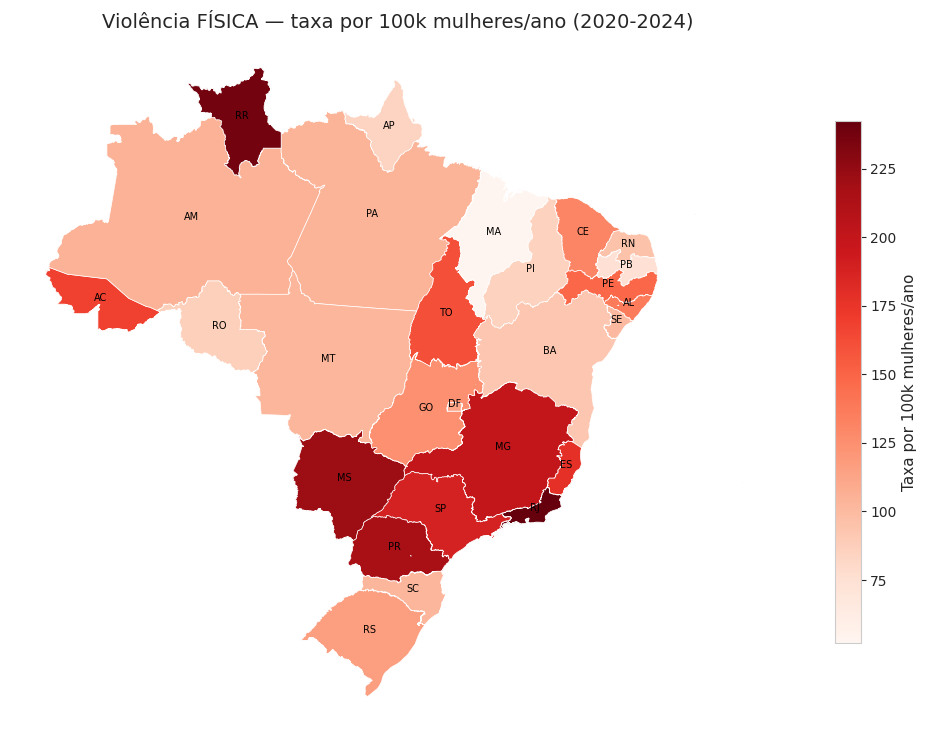

In [33]:
plot_mapa(gdf, taxa_fis, 'Violência FÍSICA — taxa por 100k mulheres/ano (2020-2024)', 'Reds')


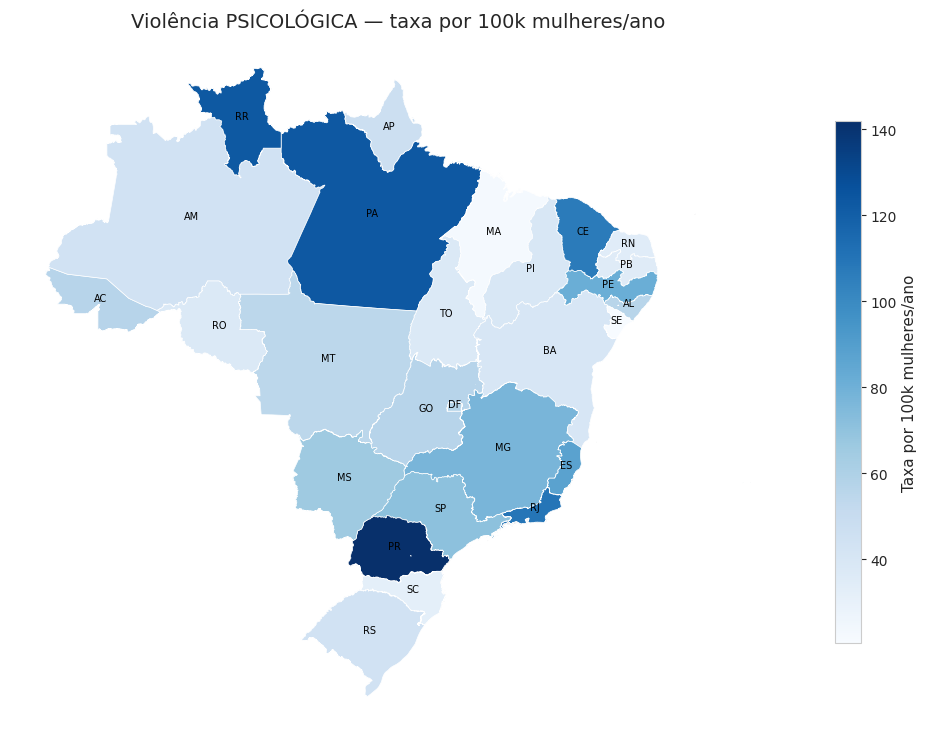

In [34]:
plot_mapa(gdf, taxa_psi, 'Violência PSICOLÓGICA — taxa por 100k mulheres/ano', 'Blues')


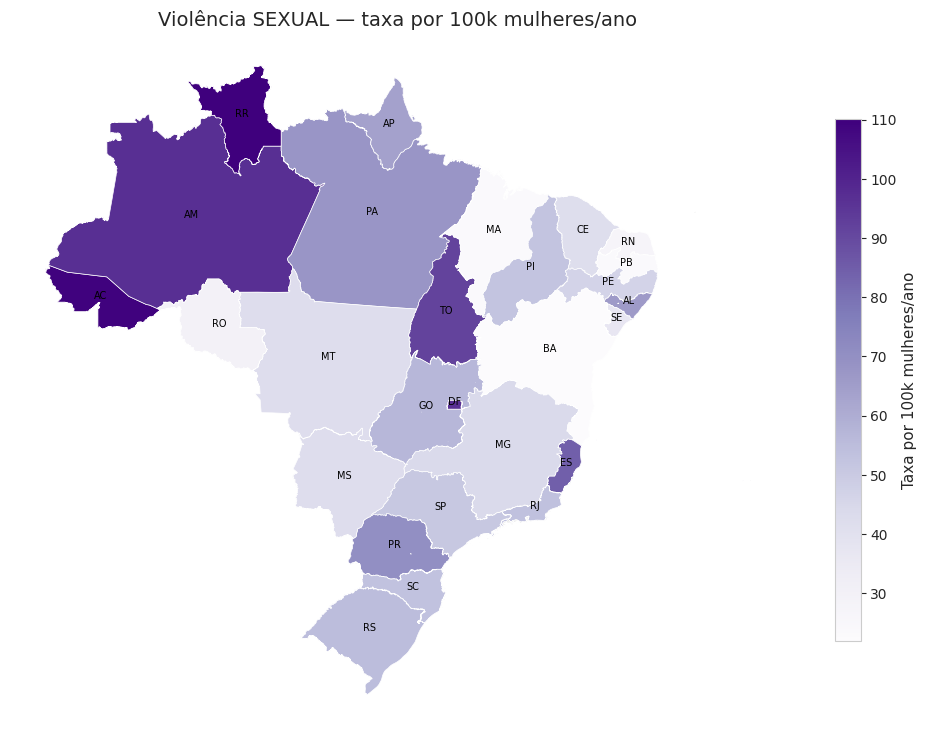

In [35]:
plot_mapa(gdf, taxa_sex, 'Violência SEXUAL — taxa por 100k mulheres/ano', 'Purples')

In [38]:
# Top 10 estados por TAXA (proporcional à população feminina)

print('Taxas de notificação por 100 mil mulheres/ano (2020-2024):\n')

for taxa, nome in [(taxa_fis, 'FÍSICA'),
                    (taxa_psi, 'PSICOLÓGICA'),
                    (taxa_sex, 'SEXUAL')]:
    top = taxa.sort_values(ascending=False).head(10)
    print(f'\n=== Top 10 — Violência {nome} ===')
    for i, (uf, t) in enumerate(top.items(), 1):
        print(f'  {i:2d}. {uf}: {t:>6.1f} por 100k mulheres/ano')

Taxas de notificação por 100 mil mulheres/ano (2020-2024):


=== Top 10 — Violência FÍSICA ===
   1. RJ:  242.3 por 100k mulheres/ano
   2. RR:  237.6 por 100k mulheres/ano
   3. MS:  221.0 por 100k mulheres/ano
   4. PR:  216.0 por 100k mulheres/ano
   5. MG:  199.7 por 100k mulheres/ano
   6. SP:  188.5 por 100k mulheres/ano
   7. ES:  178.0 por 100k mulheres/ano
   8. AC:  168.6 por 100k mulheres/ano
   9. TO:  161.0 por 100k mulheres/ano
  10. PE:  148.2 por 100k mulheres/ano

=== Top 10 — Violência PSICOLÓGICA ===
   1. PR:  141.9 por 100k mulheres/ano
   2. PA:  123.4 por 100k mulheres/ano
   3. RR:  122.7 por 100k mulheres/ano
   4. RJ:  109.3 por 100k mulheres/ano
   5. CE:  106.9 por 100k mulheres/ano
   6. ES:   87.6 por 100k mulheres/ano
   7. PE:   81.7 por 100k mulheres/ano
   8. MG:   77.1 por 100k mulheres/ano
   9. SP:   71.1 por 100k mulheres/ano
  10. MS:   65.8 por 100k mulheres/ano

=== Top 10 — Violência SEXUAL ===
   1. RR:  110.1 por 100k mulheres/ano
   2. AC:  

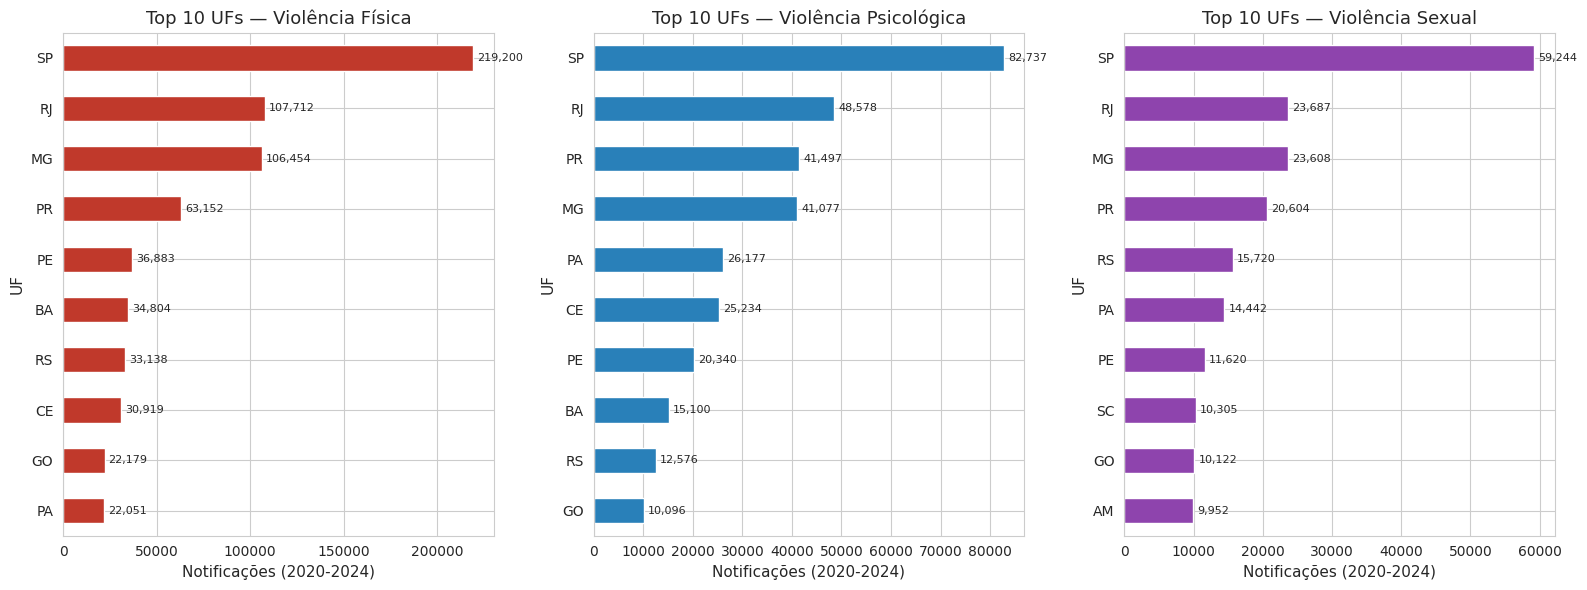

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, top, nome, cor in zip(axes,
                                [top_fis, top_psi, top_sex],
                                ['Física', 'Psicológica', 'Sexual'],
                                ['#c0392b', '#2980b9', '#8e44ad']):
    top.sort_values().plot(kind='barh', ax=ax, color=cor)
    ax.set_title(f'Top 10 UFs — Violência {nome}')
    ax.set_xlabel('Notificações (2020-2024)')

    # Anota valores
    for i, v in enumerate(top.sort_values()):
        ax.text(v + top.max()*0.01, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

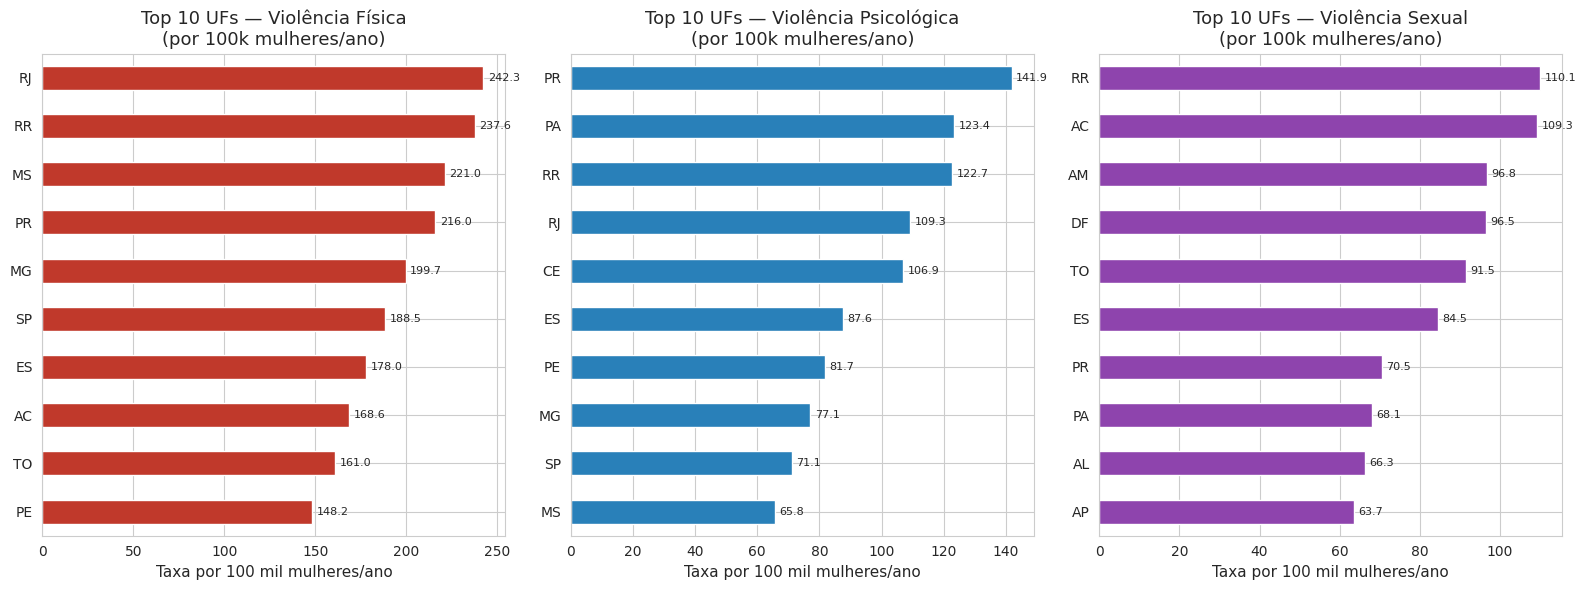

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, taxa, nome, cor in zip(axes,
                                 [taxa_fis, taxa_psi, taxa_sex],
                                 ['Física', 'Psicológica', 'Sexual'],
                                 ['#c0392b', '#2980b9', '#8e44ad']):
    top = taxa.sort_values(ascending=False).head(10)
    top.sort_values().plot(kind='barh', ax=ax, color=cor)
    ax.set_title(f'Top 10 UFs — Violência {nome}\n(por 100k mulheres/ano)')
    ax.set_xlabel('Taxa por 100 mil mulheres/ano')

    for i, v in enumerate(top.sort_values()):
        ax.text(v + top.max()*0.01, i, f'{v:.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 4.1 — ÁLCOOL × GRAVIDADE

In [46]:
# 1. Verifica preenchimento dos meios de agressão
meios = ['AG_FORCA', 'AG_AMEACA', 'AG_OBJETO', 'AG_ENFOR',
         'AG_CORTE', 'AG_QUENTE', 'AG_ENVEN', 'AG_FOGO']

print('Preenchimento dos meios de agressão:\n')
for m in meios:
    if m not in df.columns:
        print(f'  {m}: NÃO EXISTE NA BASE')
        continue
    sim = (df[m] == '1').sum()
    nao = (df[m] == '2').sum()
    ign = (df[m] == '9').sum() + df[m].isna().sum()
    pct_sim = 100 * sim / len(df)
    print(f'  {m:10s}: Sim={sim:>7,} ({pct_sim:.1f}%) | Não={nao:>7,} | Ign/NaN={ign:>7,}')

Preenchimento dos meios de agressão:

  AG_FORCA  : Sim=674,566 (40.2%) | Não=943,453 | Ign/NaN= 35,976
  AG_AMEACA : Sim=269,664 (16.1%) | Não=1,332,536 | Ign/NaN= 44,611
  AG_OBJETO : Sim= 66,139 (3.9%) | Não=1,535,119 | Ign/NaN= 43,090
  AG_ENFOR  : Sim= 82,958 (4.9%) | Não=1,519,843 | Ign/NaN= 42,845
  AG_CORTE  : Sim=168,096 (10.0%) | Não=1,436,587 | Ign/NaN= 41,498
  AG_QUENTE : Sim= 14,137 (0.8%) | Não=1,587,689 | Ign/NaN= 42,695
  AG_ENVEN  : Sim=376,857 (22.5%) | Não=1,232,660 | Ign/NaN= 37,558
  AG_FOGO   : Sim= 19,665 (1.2%) | Não=1,581,735 | Ign/NaN= 42,702


In [48]:
# 2. Constrói categoria de gravidade baseada nos meios
def classificar_gravidade(row):
    # Alta letalidade
    if row.get('AG_FOGO') == '1' or row.get('AG_ENVEN') == '1':
        return '4 - Alta letalidade'
    if row.get('AG_QUENTE') == '1':
        return '4 - Alta letalidade'
    # Média letalidade
    if row.get('AG_CORTE') == '1' or row.get('AG_ENFOR') == '1':
        return '3 - Média letalidade'
    # Baixa letalidade
    if row.get('AG_OBJETO') == '1':
        return '2 - Baixa letalidade'
    if row.get('AG_FORCA') == '1':
        return '1 - Força corporal'
    # Sem agressão física
    if row.get('AG_AMEACA') == '1':
        return '0 - Apenas ameaça'
    return 'Sem informação'

df['GRAVIDADE'] = df.apply(classificar_gravidade, axis=1)

# Distribuição
grav_dist = df['GRAVIDADE'].value_counts()
print('Distribuição de gravidade:\n')
print(grav_dist)
print(f'\n% das notificações com gravidade conhecida: {100*(df["GRAVIDADE"] != "Sem informação").mean():.1f}%')

Distribuição de gravidade:

GRAVIDADE
1 - Força corporal      550688
4 - Alta letalidade     408473
Sem informação          346241
3 - Média letalidade    221568
0 - Apenas ameaça       102139
2 - Baixa letalidade     48192
Name: count, dtype: int64

% das notificações com gravidade conhecida: 79.4%


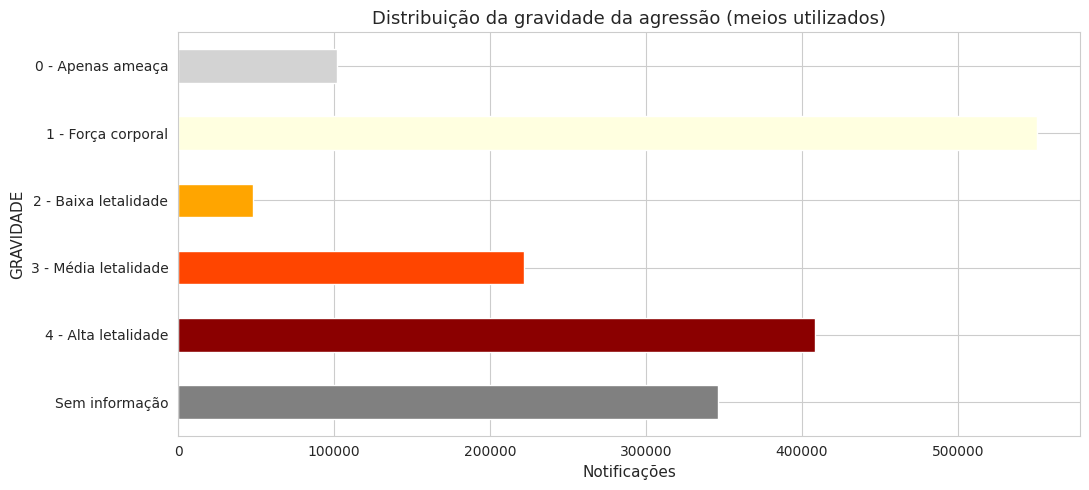

In [49]:
# 3. Visualiza distribuição
ordem = ['0 - Apenas ameaça', '1 - Força corporal', '2 - Baixa letalidade',
         '3 - Média letalidade', '4 - Alta letalidade', 'Sem informação']

fig, ax = plt.subplots(figsize=(11, 5))
df['GRAVIDADE'].value_counts().reindex(ordem).dropna().plot(
    kind='barh', ax=ax, color=['lightgray', 'lightyellow', 'orange',
                                'orangered', 'darkred', 'gray'])
ax.set_title('Distribuição da gravidade da agressão (meios utilizados)')
ax.set_xlabel('Notificações')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [50]:
# 4. ÁLCOOL × GRAVIDADE
sub = df[df['AUTOR_ALCO'].isin(['1', '2'])].copy()
sub['ALCOOL'] = sub['AUTOR_ALCO'].map({'1': 'Sim', '2': 'Não'})
sub = sub[sub['GRAVIDADE'] != 'Sem informação']

# Tabela cruzada normalizada por linha
tab = pd.crosstab(sub['ALCOOL'], sub['GRAVIDADE'], normalize='index') * 100
tab = tab.reindex(columns=ordem[:-1])  # tira "Sem informação"

print('% de cada nível de gravidade dentro de cada grupo de álcool:\n')
print(tab.round(1))

% de cada nível de gravidade dentro de cada grupo de álcool:

GRAVIDADE  0 - Apenas ameaça  1 - Força corporal  2 - Baixa letalidade  \
ALCOOL                                                                   
Não                      8.0                32.9                   2.9   
Sim                      8.8                53.2                   4.9   

GRAVIDADE  3 - Média letalidade  4 - Alta letalidade  
ALCOOL                                                
Não                        16.7                 39.6  
Sim                        19.4                 13.7  


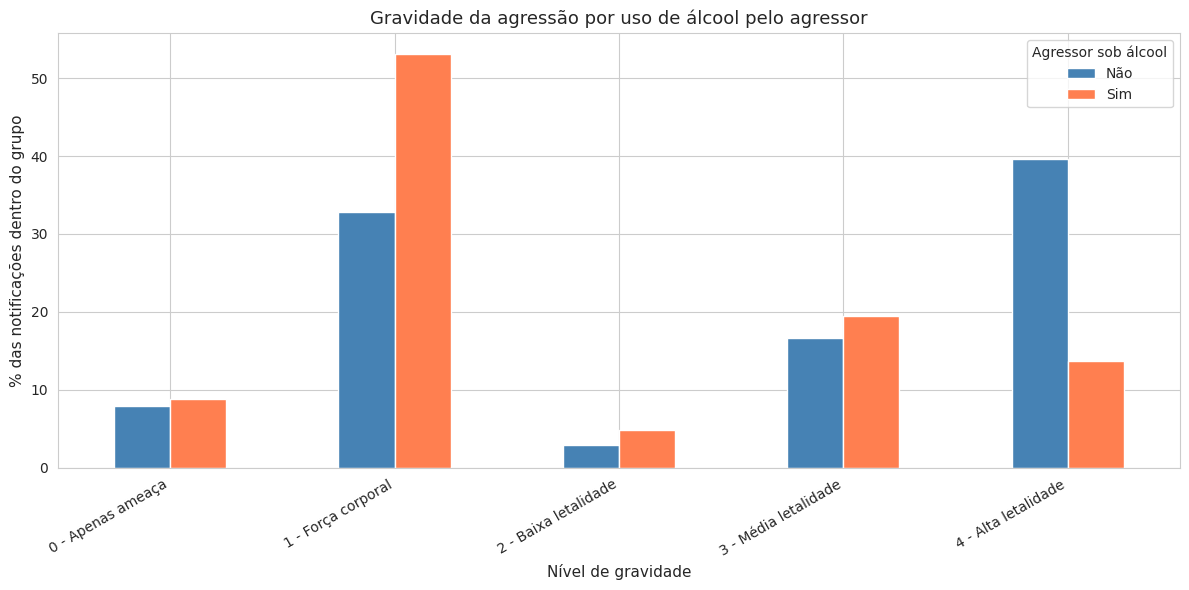

In [51]:
# 5. Visualização
fig, ax = plt.subplots(figsize=(12, 6))
tab.T.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Gravidade da agressão por uso de álcool pelo agressor')
ax.set_ylabel('% das notificações dentro do grupo')
ax.set_xlabel('Nível de gravidade')
ax.legend(title='Agressor sob álcool')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---

# Bloco 5 — Síntese social: iniquidades

In [55]:
# Composição racial dentre as vítimas de cada tipo de violência
# Cada coluna soma 100%

ordem_racas = ['Branca', 'Preta', 'Parda', 'Amarela', 'Indígena', 'Ignorado']

# Para cada tipo, calcula a distribuição racial
composicao = {}
for tipo, nome in [('y_fisic', 'Física'),
                    ('y_psico', 'Psicológica'),
                    ('y_sexu', 'Sexual')]:
    sub = df[df[tipo] == 1]
    dist = sub['RACA'].value_counts(normalize=True) * 100
    composicao[nome] = dist.reindex(ordem_racas).fillna(0)

comp_df = pd.DataFrame(composicao)
print('Composição racial das vítimas, por tipo de violência (%):\n')
print(comp_df.round(1))
print('\n(Cada coluna soma 100%)')

Composição racial das vítimas, por tipo de violência (%):

          Física  Psicológica  Sexual
RACA                                 
Branca      35.8         36.0    35.3
Preta       10.2         11.2     9.7
Parda       46.2         46.2    48.4
Amarela      1.0          1.0     0.9
Indígena     1.0          0.9     1.4
Ignorado     5.5          4.4     4.0

(Cada coluna soma 100%)


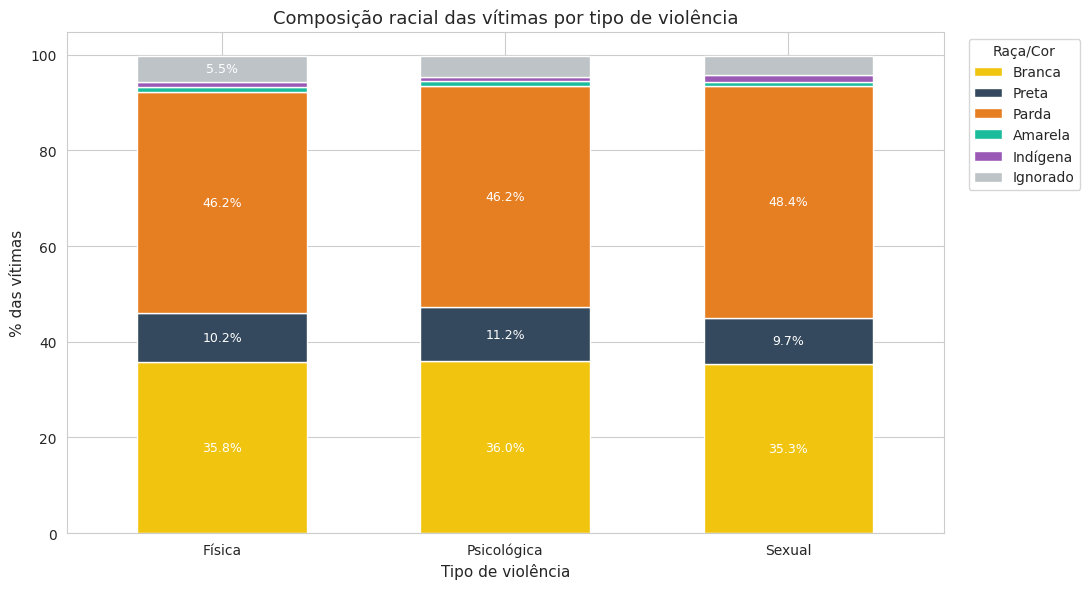

In [56]:
fig, ax = plt.subplots(figsize=(11, 6))

cores = ['#f1c40f',  # Branca - amarelo claro
         '#34495e',  # Preta - azul escuro
         '#e67e22',  # Parda - laranja
         '#1abc9c',  # Amarela - turquesa
         '#9b59b6',  # Indígena - roxo
         '#bdc3c7']  # Ignorado - cinza

comp_df.T.plot(kind='bar', stacked=True, ax=ax, color=cores, width=0.6)

ax.set_title('Composição racial das vítimas por tipo de violência')
ax.set_ylabel('% das vítimas')
ax.set_xlabel('Tipo de violência')
ax.legend(title='Raça/Cor', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)

# Anota porcentagens dentro das barras (só onde > 5% pra não poluir)
for c in ax.containers:
    labels = [f'{v:.1f}%' if v > 5 else '' for v in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='white')

plt.tight_layout()
plt.show()

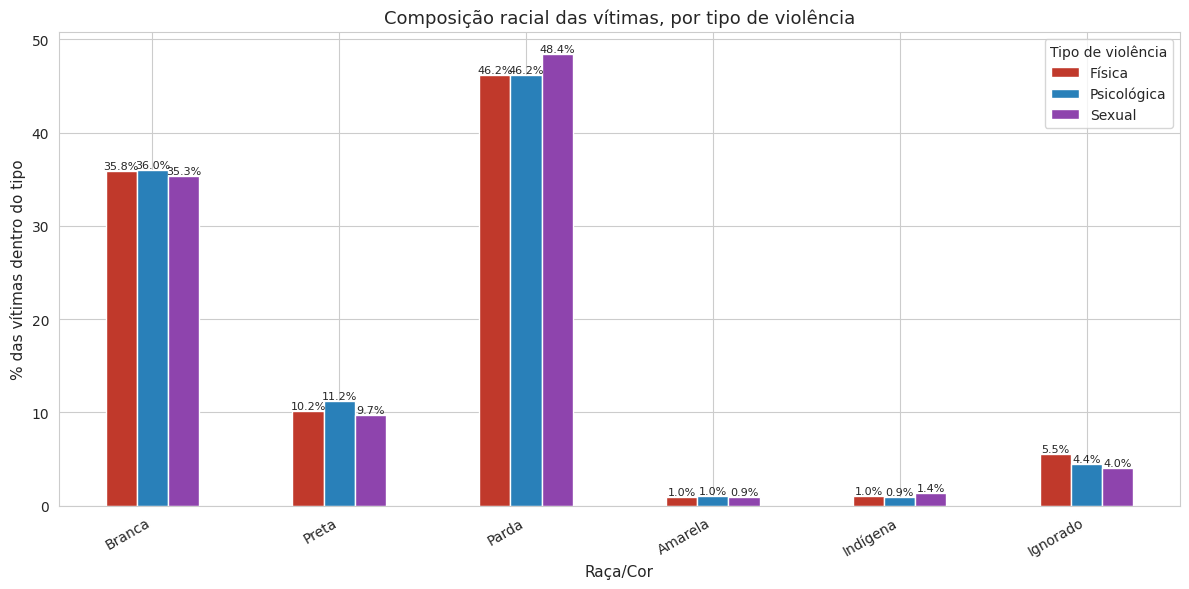

In [57]:
fig, ax = plt.subplots(figsize=(12, 6))
comp_df.plot(kind='bar', ax=ax, color=['#c0392b', '#2980b9', '#8e44ad'])

ax.set_title('Composição racial das vítimas, por tipo de violência')
ax.set_ylabel('% das vítimas dentro do tipo')
ax.set_xlabel('Raça/Cor')
ax.legend(title='Tipo de violência')
plt.xticks(rotation=30, ha='right')

for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', fontsize=8)

plt.tight_layout()
plt.show()

In [58]:
# População feminina por raça/cor no Brasil (Censo IBGE 2022)
# Total feminino: ~108,7 milhões
POP_FEM_RACA = {
    'Branca':   47_280_000,   # 43,5%
    'Preta':    11_087_000,   # 10,2%
    'Parda':    49_241_000,   # 45,3%
    'Amarela':     435_000,   # 0,4%
    'Indígena':    652_000,   # 0,6%
}
TOTAL_POP_FEM = sum(POP_FEM_RACA.values())

# Período da nossa base
ANOS_BASE = 5  # 2020-2024

print('=' * 80)
print('RISCO DE SER VÍTIMA NOTIFICADA DE VIOLÊNCIA, POR RAÇA/COR')
print('=' * 80)

# Total geral (qualquer tipo de violência - todas as mulheres da base)
total_vitimas = len(df)
risco_geral = total_vitimas / TOTAL_POP_FEM / ANOS_BASE
print(f'\nTotal de mulheres vítimas notificadas: {total_vitimas:,}')
print(f'População feminina BR: {TOTAL_POP_FEM:,}')
print(f'Risco anual médio: 1 a cada {1/risco_geral:,.0f} mulheres é vítima/ano')
print(f'Taxa: {risco_geral*100_000:.1f} vítimas por 100 mil mulheres/ano\n')

# Por raça
print('-' * 80)
print(f'{"Raça":<12} {"População":>13} {"Vítimas":>10} {"1 a cada":>14} {"vs média":>10}')
print('-' * 80)

resultados = {}
for raca, pop in POP_FEM_RACA.items():
    vitimas = (df['RACA'] == raca).sum()
    if vitimas == 0:
        continue
    risco = vitimas / pop / ANOS_BASE
    uma_em_cada = 1 / risco
    razao = risco / risco_geral  # quantas vezes acima/abaixo da média

    resultados[raca] = {
        'populacao': pop,
        'vitimas': vitimas,
        'risco_anual': risco,
        'uma_em_cada': uma_em_cada,
        'razao_media': razao
    }

    print(f'{raca:<12} {pop:>13,} {vitimas:>10,} {uma_em_cada:>13,.0f} {razao:>9.2f}x')

RISCO DE SER VÍTIMA NOTIFICADA DE VIOLÊNCIA, POR RAÇA/COR

Total de mulheres vítimas notificadas: 1,677,301
População feminina BR: 108,695,000
Risco anual médio: 1 a cada 324 mulheres é vítima/ano
Taxa: 308.6 vítimas por 100 mil mulheres/ano

--------------------------------------------------------------------------------
Raça             População    Vítimas       1 a cada   vs média
--------------------------------------------------------------------------------
Branca          47,280,000    650,471           363      0.89x
Preta           11,087,000    149,883           370      0.88x
Parda           49,241,000    752,498           327      0.99x
Amarela            435,000     16,292           134      2.43x
Indígena           652,000     14,588           223      1.45x


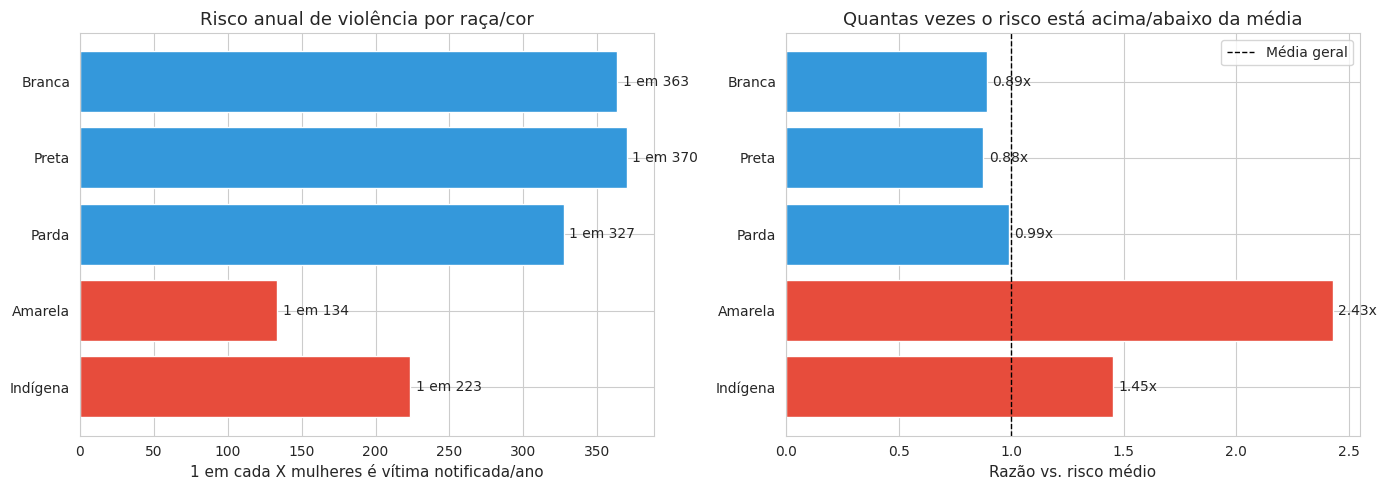

In [59]:
# Gráfico 1: "1 em cada X" — quanto MENOR o número, mais alto o risco
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

racas = list(resultados.keys())
um_em_cada = [resultados[r]['uma_em_cada'] for r in racas]
razao = [resultados[r]['razao_media'] for r in racas]

cores = ['#3498db' if r < 1 else '#e74c3c' for r in razao]

# Painel 1: 1 em cada X
axes[0].barh(racas, um_em_cada, color=cores)
axes[0].set_xlabel('1 em cada X mulheres é vítima notificada/ano')
axes[0].set_title('Risco anual de violência por raça/cor')
axes[0].invert_yaxis()
for i, v in enumerate(um_em_cada):
    axes[0].text(v + max(um_em_cada)*0.01, i, f'1 em {v:,.0f}',
                  va='center', fontsize=10)

# Painel 2: razão vs média (acima/abaixo de 1)
axes[1].barh(racas, razao, color=cores)
axes[1].axvline(1, color='black', linestyle='--', linewidth=1, label='Média geral')
axes[1].set_xlabel('Razão vs. risco médio')
axes[1].set_title('Quantas vezes o risco está acima/abaixo da média')
axes[1].invert_yaxis()
axes[1].legend()
for i, v in enumerate(razao):
    axes[1].text(v + max(razao)*0.01, i, f'{v:.2f}x',
                  va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [60]:
# Risco por raça E por tipo de violência
print('=' * 90)
print('"1 EM CADA X MULHERES" SOFRE VIOLÊNCIA — POR RAÇA E TIPO')
print('=' * 90)

print(f'\n{"Raça":<12} {"Física":>20} {"Psicológica":>20} {"Sexual":>20}')
print('-' * 90)

risco_por_tipo = {}
for raca, pop in POP_FEM_RACA.items():
    if raca not in df['RACA'].unique():
        continue
    sub = df[df['RACA'] == raca]

    linha = []
    for tipo in ['y_fisic', 'y_psico', 'y_sexu']:
        n = (sub[tipo] == 1).sum()
        if n == 0:
            linha.append('—')
        else:
            uma_em = pop / n * ANOS_BASE
            linha.append(f'1 em {uma_em:,.0f}')

    print(f'{raca:<12} {linha[0]:>20} {linha[1]:>20} {linha[2]:>20}')
    risco_por_tipo[raca] = linha

"1 EM CADA X MULHERES" SOFRE VIOLÊNCIA — POR RAÇA E TIPO

Raça                       Física          Psicológica               Sexual
------------------------------------------------------------------------------------------
Branca                   1 em 797           1 em 1,710           1 em 2,467
Preta                    1 em 658           1 em 1,289           1 em 2,104
Parda                    1 em 645           1 em 1,387           1 em 1,876
Amarela                  1 em 270             1 em 569             1 em 867
Indígena                 1 em 379             1 em 919             1 em 882


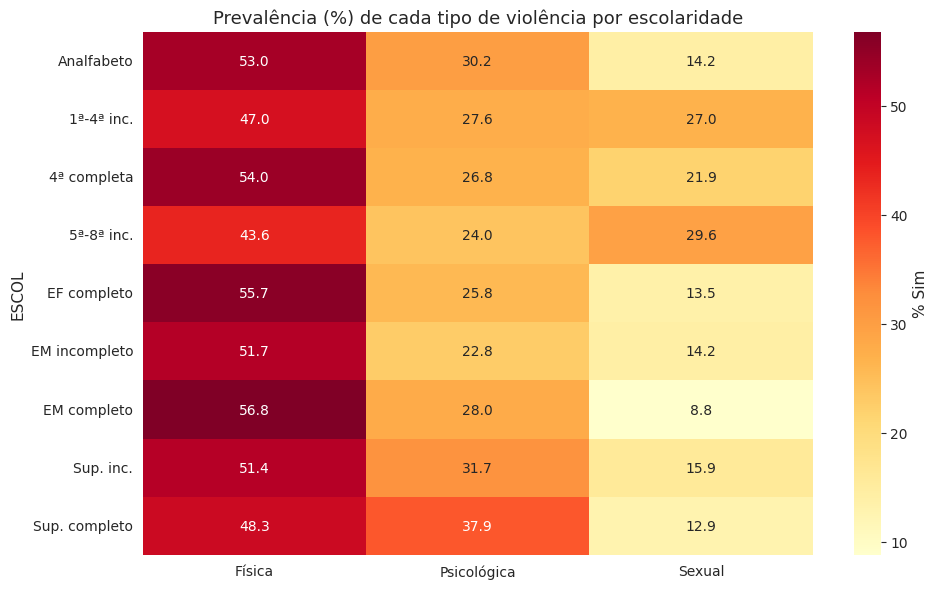

In [54]:
# Tipo de violência por escolaridade
ordem = ['Analfabeto','1ª-4ª inc.','4ª completa','5ª-8ª inc.',
         'EF completo','EM incompleto','EM completo',
         'Sup. inc.','Sup. completo']
tab_esc = df.groupby('ESCOL')[['y_fisic','y_psico','y_sexu']].mean() * 100
tab_esc = tab_esc.reindex(ordem).dropna()
tab_esc.columns = ['Física','Psicológica','Sexual']

plt.figure(figsize=(10, 6))
sns.heatmap(tab_esc, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label':'% Sim'})
plt.title('Prevalência (%) de cada tipo de violência por escolaridade')
plt.tight_layout(); plt.show()

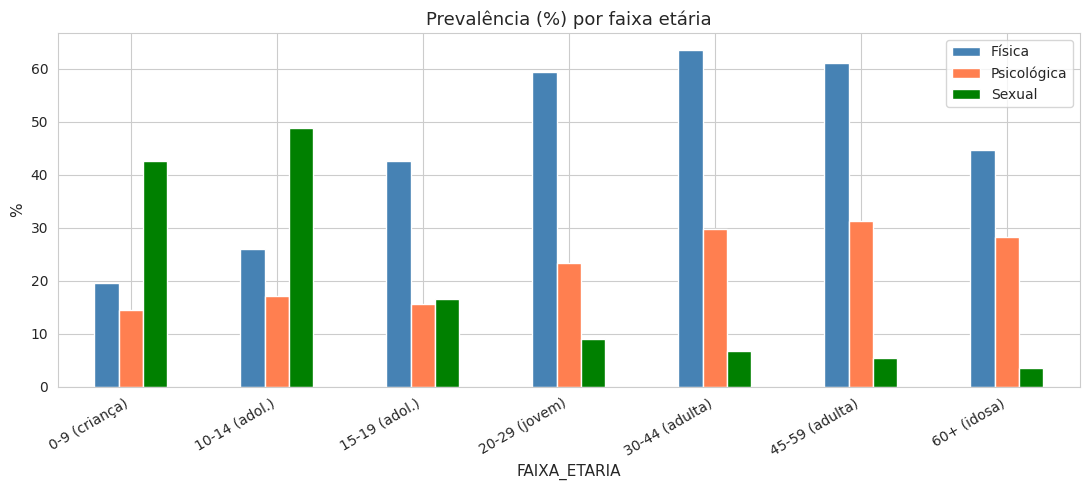

In [61]:
# Tipo de violência por faixa etária
ordem_faixas = ['0-9 (criança)','10-14 (adol.)','15-19 (adol.)',
                '20-29 (jovem)','30-44 (adulta)','45-59 (adulta)','60+ (idosa)']
tab_faixa = df.groupby('FAIXA_ETARIA')[['y_fisic','y_psico','y_sexu']].mean() * 100
tab_faixa = tab_faixa.reindex(ordem_faixas)
tab_faixa.columns = ['Física','Psicológica','Sexual']

fig, ax = plt.subplots(figsize=(11, 5))
tab_faixa.plot(kind='bar', ax=ax, color=['steelblue','coral','green'])
ax.set_title('Prevalência (%) por faixa etária')
ax.set_ylabel('%')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

In [63]:
# Filtra: violência sexual + idade < 15 anos
sexu_menor = df[(df['y_sexu'] == 1) & (df['IDADE'] < 15)].copy()

print(f'Violência sexual contra meninas (<15 anos): {len(sexu_menor):,} casos')
print(f'(% do total de violência sexual: {100*len(sexu_menor)/(df["y_sexu"]==1).sum():.1f}%)')
print(f'Distribuição etária dentro do recorte:')
print(sexu_menor['IDADE'].describe().round(1))

Violência sexual contra meninas (<15 anos): 159,430 casos
(% do total de violência sexual: 58.8%)
Distribuição etária dentro do recorte:
count    159430.0
mean          9.0
std           4.2
min           0.0
25%           5.0
50%          10.0
75%          13.0
max          14.0
Name: IDADE, dtype: float64



Local de ocorrência — Violência sexual contra meninas <15 anos:

  Residência               : 113,138 (71.0%)
  Ignorado                 :  18,200 (11.4%)
  Outro                    :  13,755 (8.6%)
  Via pública              :   5,570 (3.5%)
  Escola                   :   5,513 (3.5%)
  Hab. coletiva            :   1,077 (0.7%)
  Comércio                 :     856 (0.5%)
  Bar                      :     658 (0.4%)
  Local esportivo          :     381 (0.2%)
  Indústria                :     179 (0.1%)
  Não informado            :     103 (0.1%)


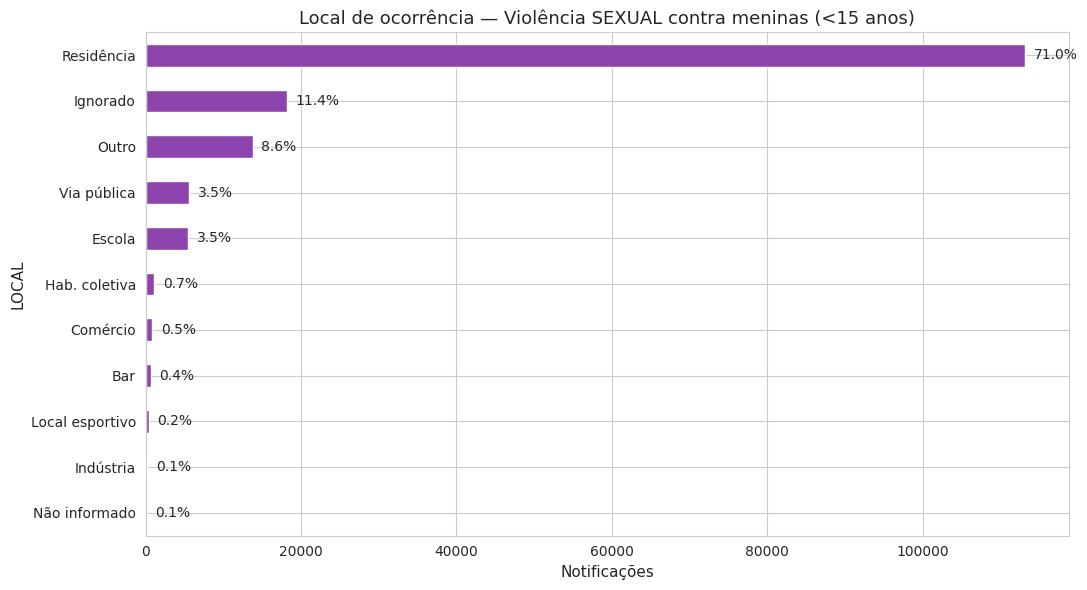

In [64]:
# Local de ocorrência
sexu_local = sexu_menor['LOCAL'].value_counts()
prop = (sexu_local / len(sexu_menor) * 100).round(1)

print('\nLocal de ocorrência — Violência sexual contra meninas <15 anos:\n')
for local, n in sexu_local.items():
    print(f'  {local:25s}: {n:>7,} ({prop[local]:.1f}%)')

fig, ax = plt.subplots(figsize=(11, 6))
sexu_local.plot(kind='barh', ax=ax, color='#8e44ad')
ax.set_title('Local de ocorrência — Violência SEXUAL contra meninas (<15 anos)')
ax.set_xlabel('Notificações')
ax.invert_yaxis()

for i, (local, n) in enumerate(sexu_local.items()):
    ax.text(n + sexu_local.max()*0.01, i, f'{prop[local]:.1f}%',
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [65]:
# Sexo do agressor
sexu_autor = sexu_menor['AUTOR_SEXO'].map(MAP_AUTOR_SEXO).value_counts()
prop_autor = (sexu_autor / sexu_autor.sum() * 100).round(1)

print('\nSexo do agressor — Violência sexual contra meninas <15 anos:\n')
for sexo, n in sexu_autor.items():
    print(f'  {sexo:15s}: {n:>7,} ({prop_autor[sexo]:.1f}%)')


Sexo do agressor — Violência sexual contra meninas <15 anos:

  Masculino      : 138,797 (87.1%)
  Ignorado       :  11,986 (7.5%)
  Feminino       :   5,124 (3.2%)
  Ambos os sexos :   3,439 (2.2%)



Relação com agressor — Violência sexual contra meninas <15 anos:

  Parceiro atual           :  17,657 (11.1%)
  Ex-parceiro              :   1,879 (1.2%)
  Pai/Mãe                  :  22,495 (14.1%)
  Filho(a)/Irmão(ã)        :   4,424 (2.8%)
  Cuidador                 :   1,485 (0.9%)
  Conhecido                :  36,344 (22.8%)
  Patrão/Chefe             :      95 (0.1%)
  Desconhecido             :  12,614 (7.9%)
  Não informado            :  62,437 (39.2%)


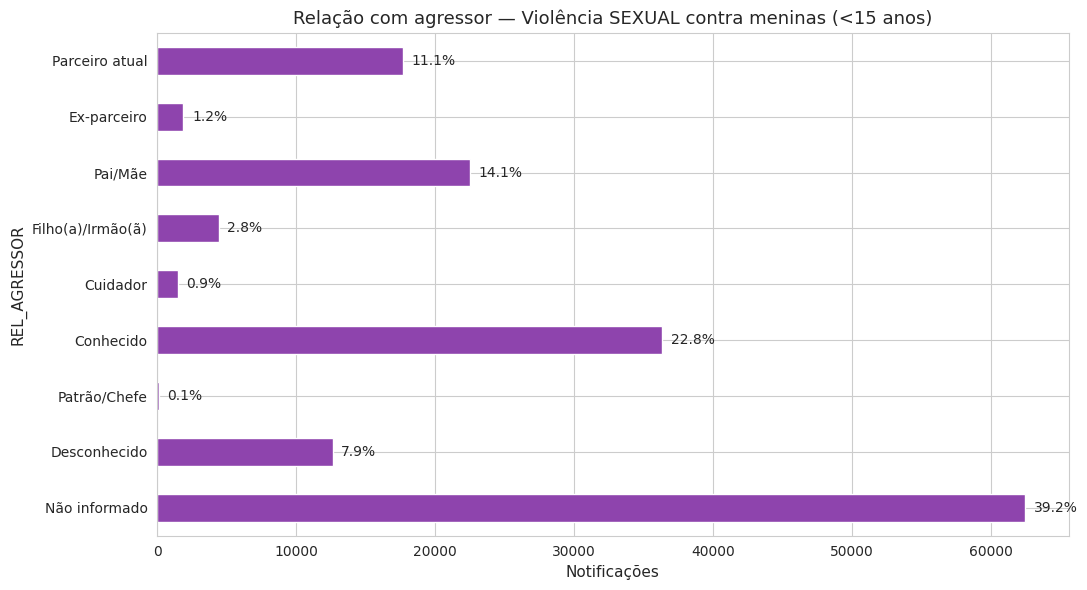

In [66]:
# Relação com agressor
ordem_rel = ['Parceiro atual', 'Ex-parceiro', 'Pai/Mãe', 'Filho(a)/Irmão(ã)',
             'Cuidador', 'Conhecido', 'Patrão/Chefe', 'Desconhecido', 'Não informado']

sexu_rel = sexu_menor['REL_AGRESSOR'].value_counts().reindex(ordem_rel).dropna()
prop_rel = (sexu_rel / sexu_rel.sum() * 100).round(1)

print('\nRelação com agressor — Violência sexual contra meninas <15 anos:\n')
for rel, n in sexu_rel.items():
    print(f'  {rel:25s}: {n:>7,} ({prop_rel[rel]:.1f}%)')

fig, ax = plt.subplots(figsize=(11, 6))
sexu_rel.plot(kind='barh', ax=ax, color='#8e44ad')
ax.set_title('Relação com agressor — Violência SEXUAL contra meninas (<15 anos)')
ax.set_xlabel('Notificações')
ax.invert_yaxis()

for i, (rel, n) in enumerate(sexu_rel.items()):
    ax.text(n + sexu_rel.max()*0.01, i, f'{prop_rel[rel]:.1f}%',
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

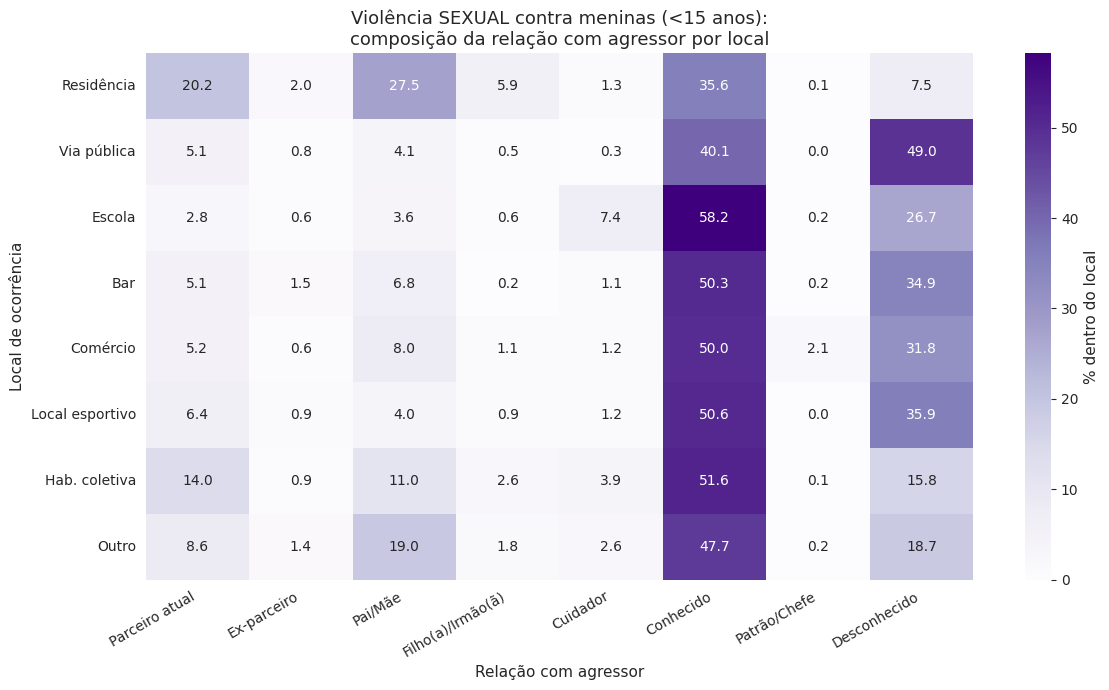

In [67]:
# Cruzamento local × relação para o recorte de meninas
sub = sexu_menor[
    sexu_menor['REL_AGRESSOR'].isin(ordem_rel[:-1]) &
    sexu_menor['LOCAL'].notna()
]

cruz = pd.crosstab(sub['LOCAL'], sub['REL_AGRESSOR'], normalize='index') * 100

locais_validos = ['Residência', 'Via pública', 'Escola', 'Bar',
                   'Comércio', 'Local esportivo', 'Hab. coletiva', 'Outro']
cruz = cruz.reindex(index=[l for l in locais_validos if l in cruz.index],
                    columns=ordem_rel[:-1])

plt.figure(figsize=(12, 7))
sns.heatmap(cruz, annot=True, fmt='.1f', cmap='Purples',
            cbar_kws={'label': '% dentro do local'})
plt.title('Violência SEXUAL contra meninas (<15 anos):\ncomposição da relação com agressor por local')
plt.xlabel('Relação com agressor')
plt.ylabel('Local de ocorrência')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---

# Bloco 6 — Revitimização (via OUT_VEZES)


In [68]:
# Distribuição
out_dist = df['OUT_VEZES'].map(MAP_SIM_NAO).value_counts(dropna=False)
prop = (out_dist / out_dist.sum() * 100).round(1)

print('Vítima informou que já sofreu violência antes?\n')
for cat, n in out_dist.items():
    print(f'  {cat}: {n:,} ({prop[cat]:.1f}%)')

Vítima informou que já sofreu violência antes?

  Sim: 742,793 (44.3%)
  Não: 576,996 (34.4%)
  Ignorado: 340,892 (20.3%)
  nan: 16,620 (1.0%)


In [69]:
# Perfil das revitimizadas: como elas se diferenciam das de primeira vez?
sub = df[df['OUT_VEZES'].isin(['1','2'])].copy()
sub['REVITIMIZADA'] = sub['OUT_VEZES'].map({'1':'Sim','2':'Não'})

# Comparação por raça
comp_raca = pd.crosstab(sub['RACA'], sub['REVITIMIZADA'], normalize='columns') * 100
print('Composição racial entre revitimizadas vs. primeira vez (%):\n')
print(comp_raca.round(1))

Composição racial entre revitimizadas vs. primeira vez (%):

REVITIMIZADA    Não   Sim
RACA                     
Amarela         0.9   1.0
Branca         41.3  40.7
Ignorado        2.9   3.6
Indígena        1.0   0.9
Não informado   0.2   0.2
Parda          45.0  43.4
Preta           8.7  10.2


In [70]:
# Por tipo de violência
print('Tipos de violência: comparação revitimizadas vs. primeira vez (%)\n')
for tipo, nome in [('y_fisic','Física'), ('y_psico','Psicológica'), ('y_sexu','Sexual')]:
    rev = sub[sub['REVITIMIZADA']=='Sim'][tipo].mean() * 100
    pri = sub[sub['REVITIMIZADA']=='Não'][tipo].mean() * 100
    diff = rev - pri
    print(f'  {nome:13s}: rev={rev:.1f}% | pri={pri:.1f}% | dif={diff:+.1f} p.p.')

Tipos de violência: comparação revitimizadas vs. primeira vez (%)

  Física       : rev=49.7% | pri=50.6% | dif=-0.9 p.p.
  Psicológica  : rev=33.0% | pri=17.1% | dif=+15.8 p.p.
  Sexual       : rev=15.2% | pri=19.1% | dif=-3.8 p.p.


In [71]:
# Revitimização por relação com agressor
tab_rel = pd.crosstab(sub['REL_AGRESSOR'], sub['REVITIMIZADA'],
                       normalize='index') * 100
tab_rel = tab_rel.sort_values('Sim', ascending=False)
print('% de revitimização por relação com agressor:\n')
print(tab_rel.round(1))

% de revitimização por relação com agressor:

REVITIMIZADA        Não   Sim
REL_AGRESSOR                 
Ex-parceiro        25.8  74.2
Parceiro atual     29.0  71.0
Filho(a)/Irmão(ã)  36.6  63.4
Patrão/Chefe       37.5  62.5
Não informado      43.6  56.4
Pai/Mãe            49.3  50.7
Cuidador           51.8  48.2
Conhecido          67.3  32.7
Desconhecido       84.2  15.8


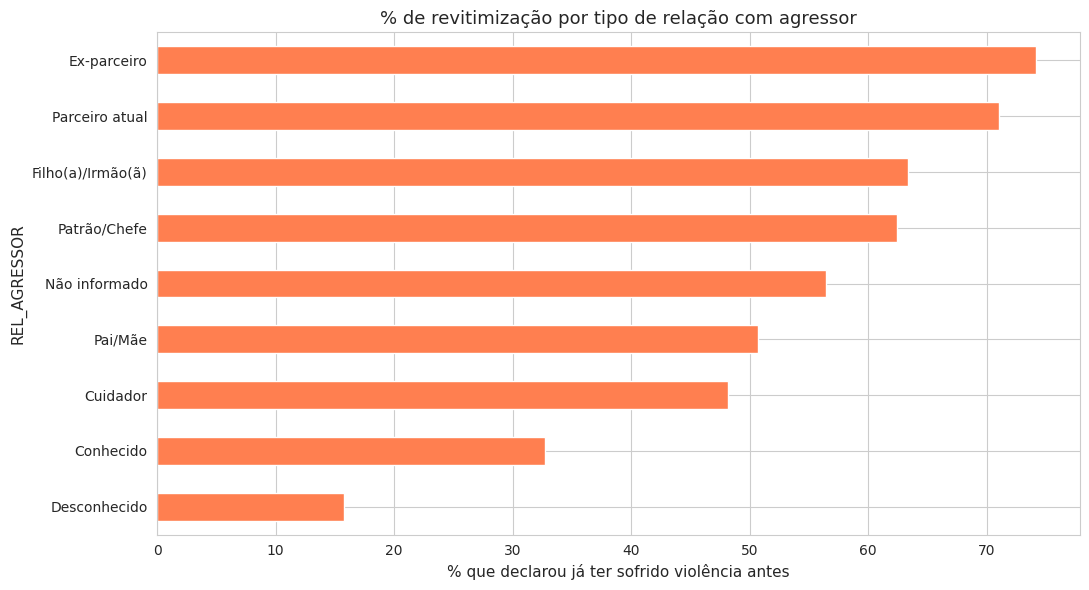

In [72]:
tab_rel['Sim'].plot(kind='barh', figsize=(11, 6), color='coral')
plt.title('% de revitimização por tipo de relação com agressor')
plt.xlabel('% que declarou já ter sofrido violência antes')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

**Hipótese central:** mulheres em violência por **parceiro íntimo** têm taxa de revitimização significativamente maior do que vítimas de violência por desconhecidos. Esta é uma hipótese clássica em VPI e os dados acima permitem testá-la.

In [73]:
# Prepara variáveis temporais a partir das datas
df['DT_OCOR_DT'] = pd.to_datetime(df['DT_OCOR'], format='%Y%m%d', errors='coerce')

df['MES'] = df['DT_OCOR_DT'].dt.month
df['DIA_SEMANA'] = df['DT_OCOR_DT'].dt.dayofweek  # 0=segunda, 6=domingo

# Hora — HORA_OCOR está como string HHMM
def extrair_hora(h):
    if pd.isna(h):
        return None
    s = str(h).zfill(4)[:2]
    try:
        h_int = int(s)
        return h_int if 0 <= h_int <= 23 else None
    except ValueError:
        return None

df['HORA'] = df['HORA_OCOR'].apply(extrair_hora)

print('Variáveis temporais criadas.')
print(f'  MES: {df["MES"].notna().sum():,} válidos')
print(f'  DIA_SEMANA: {df["DIA_SEMANA"].notna().sum():,} válidos')
print(f'  HORA: {df["HORA"].notna().sum():,} válidos')

Variáveis temporais criadas.
  MES: 1,676,912 válidos
  DIA_SEMANA: 1,676,912 válidos
  HORA: 904,941 válidos


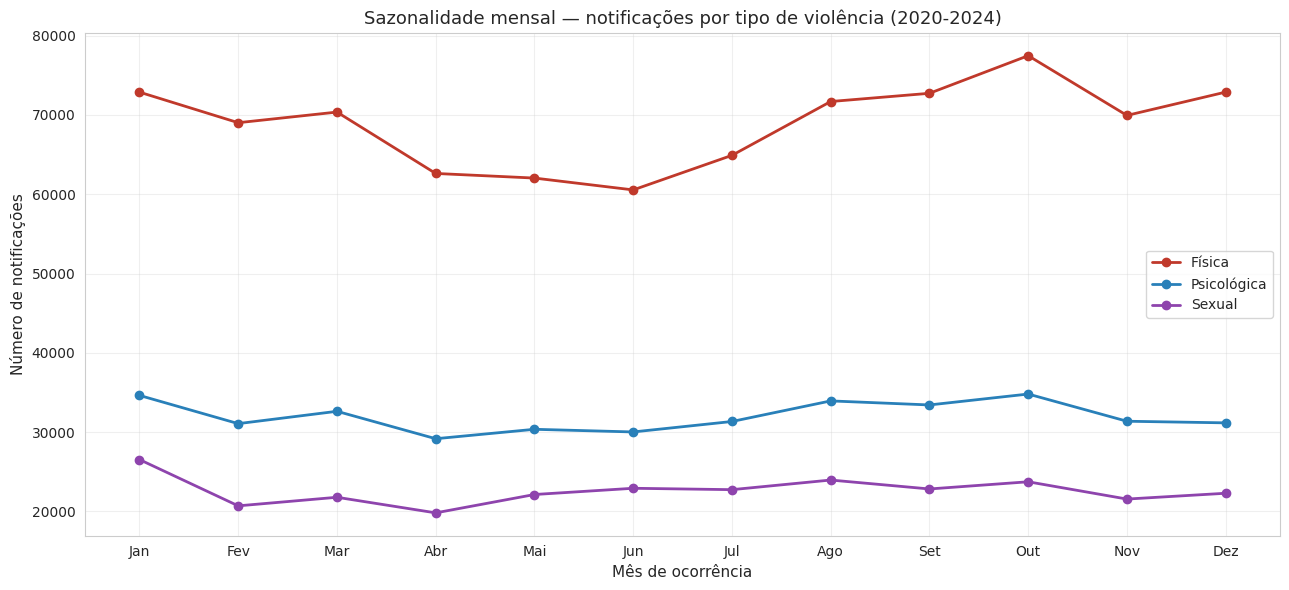

In [74]:
# Sazonalidade mensal — total e por tipo
meses_nome = ['Jan','Fev','Mar','Abr','Mai','Jun',
              'Jul','Ago','Set','Out','Nov','Dez']

fig, ax = plt.subplots(figsize=(13, 6))

# Total
total_mes = df.groupby('MES').size()
total_mes.index = [meses_nome[int(m)-1] for m in total_mes.index]

# Por tipo
for tipo, nome, cor in [('y_fisic', 'Física', '#c0392b'),
                         ('y_psico', 'Psicológica', '#2980b9'),
                         ('y_sexu', 'Sexual', '#8e44ad')]:
    serie = df[df[tipo] == 1].groupby('MES').size()
    serie.index = [meses_nome[int(m)-1] for m in serie.index]
    ax.plot(serie.index, serie.values, marker='o', linewidth=2,
            label=nome, color=cor)

ax.set_title('Sazonalidade mensal — notificações por tipo de violência (2020-2024)')
ax.set_xlabel('Mês de ocorrência')
ax.set_ylabel('Número de notificações')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

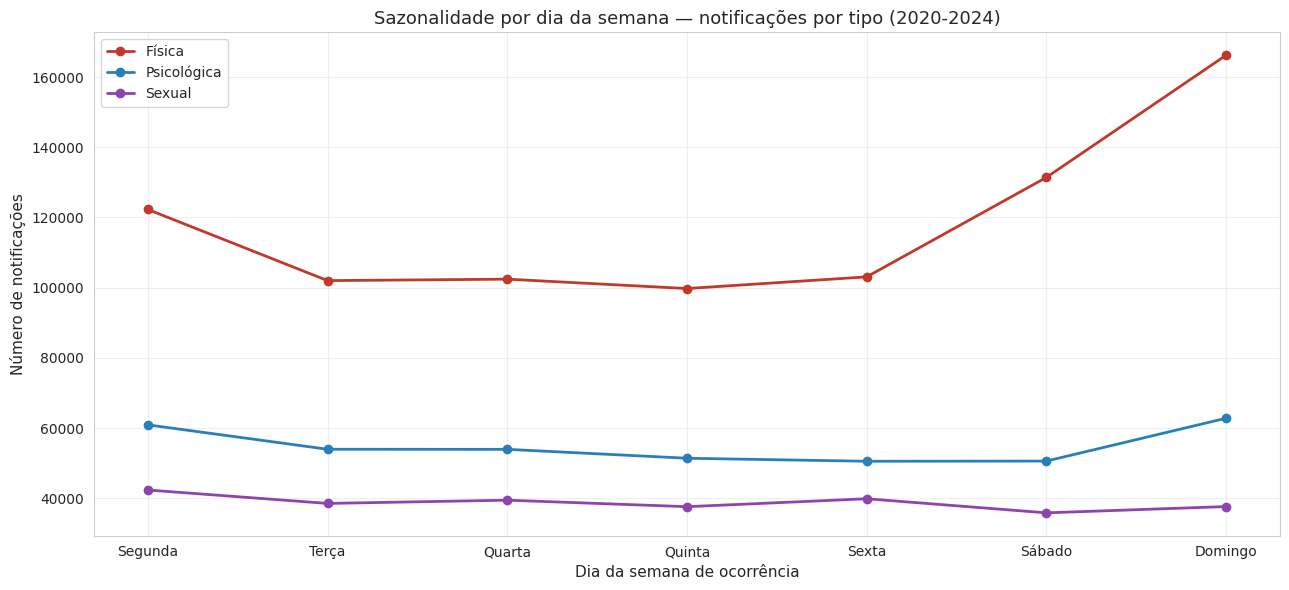

In [76]:
# Sazonalidade por dia da semana
dias_nome = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

fig, ax = plt.subplots(figsize=(13, 6))

for tipo, nome, cor in [('y_fisic', 'Física', '#c0392b'),
                         ('y_psico', 'Psicológica', '#2980b9'),
                         ('y_sexu', 'Sexual', '#8e44ad')]:
    serie = df[df[tipo] == 1].groupby('DIA_SEMANA').size()
    serie.index = [dias_nome[int(d)] for d in serie.index]
    ax.plot(serie.index, serie.values, marker='o', linewidth=2,
            label=nome, color=cor)

ax.set_title('Sazonalidade por dia da semana — notificações por tipo (2020-2024)')
ax.set_xlabel('Dia da semana de ocorrência')
ax.set_ylabel('Número de notificações')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

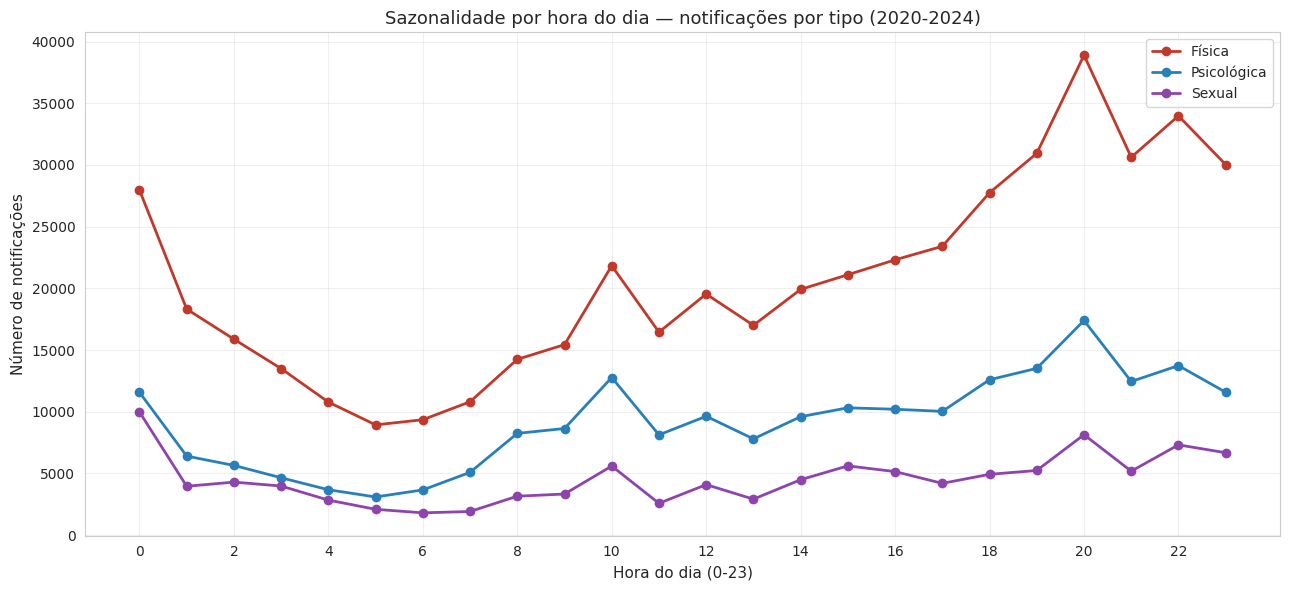

In [77]:
# Sazonalidade por hora do dia
fig, ax = plt.subplots(figsize=(13, 6))

for tipo, nome, cor in [('y_fisic', 'Física', '#c0392b'),
                         ('y_psico', 'Psicológica', '#2980b9'),
                         ('y_sexu', 'Sexual', '#8e44ad')]:
    serie = df[df[tipo] == 1].groupby('HORA').size()
    ax.plot(serie.index, serie.values, marker='o', linewidth=2,
            label=nome, color=cor)

ax.set_title('Sazonalidade por hora do dia — notificações por tipo (2020-2024)')
ax.set_xlabel('Hora do dia (0-23)')
ax.set_ylabel('Número de notificações')
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

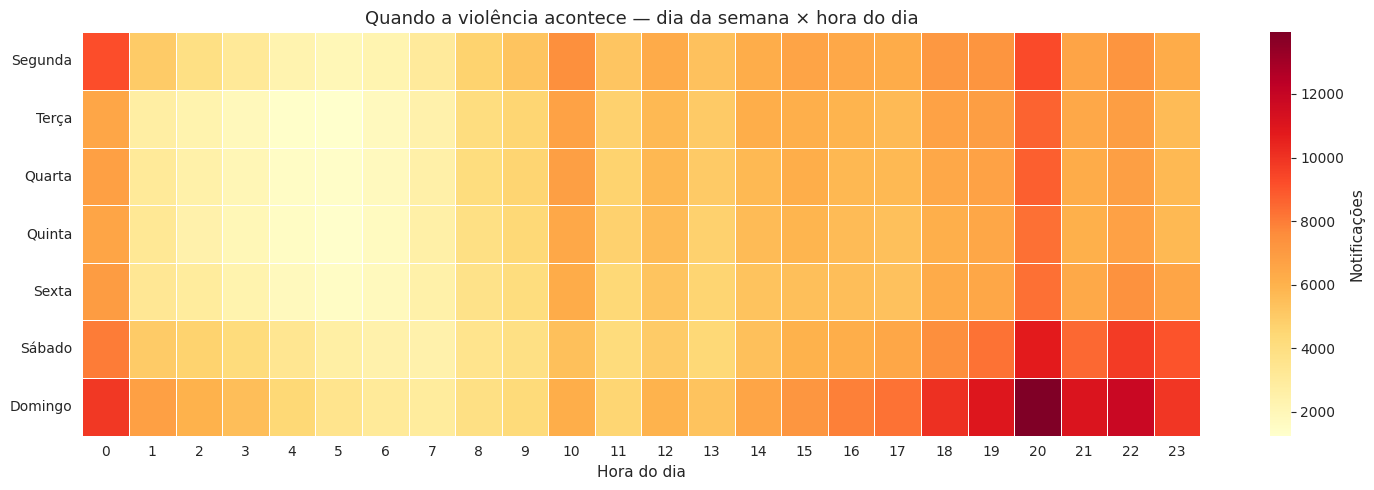

In [78]:
# Heatmap dia da semana × hora do dia (todos os tipos juntos)
sub = df.dropna(subset=['DIA_SEMANA', 'HORA']).copy()
sub['DIA_SEMANA'] = sub['DIA_SEMANA'].astype(int)
sub['HORA'] = sub['HORA'].astype(int)

cruz = pd.crosstab(sub['DIA_SEMANA'], sub['HORA'])
cruz.index = dias_nome

plt.figure(figsize=(15, 5))
sns.heatmap(cruz, cmap='YlOrRd', cbar_kws={'label': 'Notificações'},
            linewidths=0.5)
plt.title('Quando a violência acontece — dia da semana × hora do dia')
plt.xlabel('Hora do dia')
plt.ylabel('')
plt.tight_layout()
plt.show()

Mulheres com deficiência declarada: 243,258 (14.50%)

Prevalência de cada tipo de violência:

Tipo               Com def. (%)    Sem def. (%)      Razão
------------------------------------------------------------
Física                    31.6%           53.1%      0.59x
Psicológica               12.3%           25.4%      0.49x
Sexual                    10.1%           17.7%      0.57x


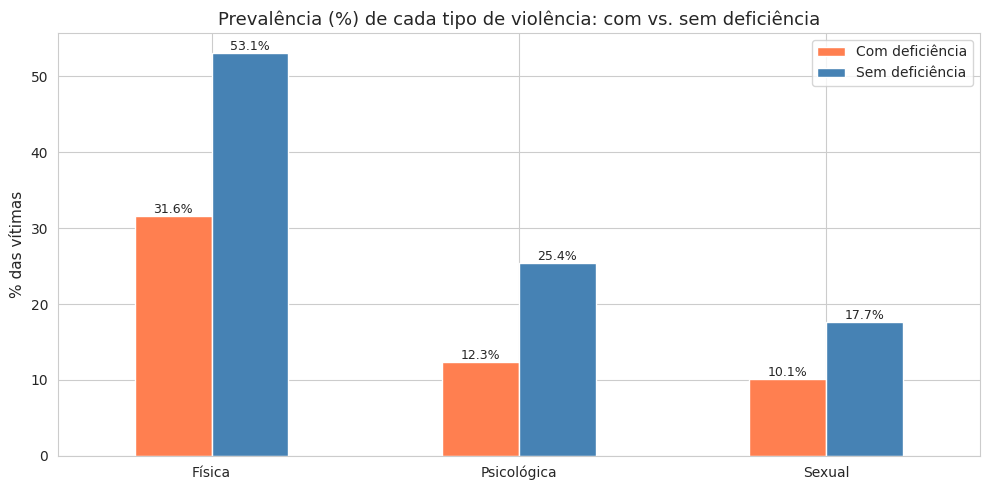

In [81]:
# ============================================================
# 3.5 — Mulheres com deficiência: prevalência e perfil
# ============================================================
# Marca quem tem qualquer deficiência declarada
df['TEM_DEFICIENCIA'] = (
    (df['DEF_FISICA'] == '1') |
    (df['DEF_MENTAL'] == '1') |
    (df['DEF_TRANS']  == '1')
).astype(int)

n_def = df['TEM_DEFICIENCIA'].sum()
print(f'Mulheres com deficiência declarada: {n_def:,} ({100*n_def/len(df):.2f}%)\n')

# Tipos de violência: com vs. sem deficiência
print('Prevalência de cada tipo de violência:\n')
print(f'{"Tipo":<15} {"Com def. (%)":>15} {"Sem def. (%)":>15} {"Razão":>10}')
print('-' * 60)
for tipo, nome in [('y_fisic', 'Física'),
                    ('y_psico', 'Psicológica'),
                    ('y_sexu',  'Sexual')]:
    com = df[df['TEM_DEFICIENCIA'] == 1][tipo].mean() * 100
    sem = df[df['TEM_DEFICIENCIA'] == 0][tipo].mean() * 100
    razao = com / sem if sem > 0 else float('inf')
    print(f'{nome:<15} {com:>14.1f}% {sem:>14.1f}% {razao:>9.2f}x')

# Visualização
tab = pd.DataFrame({
    'Com deficiência': [df[df['TEM_DEFICIENCIA']==1][t].mean()*100 for t in ['y_fisic','y_psico','y_sexu']],
    'Sem deficiência': [df[df['TEM_DEFICIENCIA']==0][t].mean()*100 for t in ['y_fisic','y_psico','y_sexu']]
}, index=['Física','Psicológica','Sexual'])

fig, ax = plt.subplots(figsize=(10, 5))
tab.plot(kind='bar', ax=ax, color=['coral', 'steelblue'])
ax.set_title('Prevalência (%) de cada tipo de violência: com vs. sem deficiência')
ax.set_ylabel('% das vítimas')
ax.set_xlabel('')
plt.xticks(rotation=0)

for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', fontsize=9)

plt.tight_layout()
plt.show()

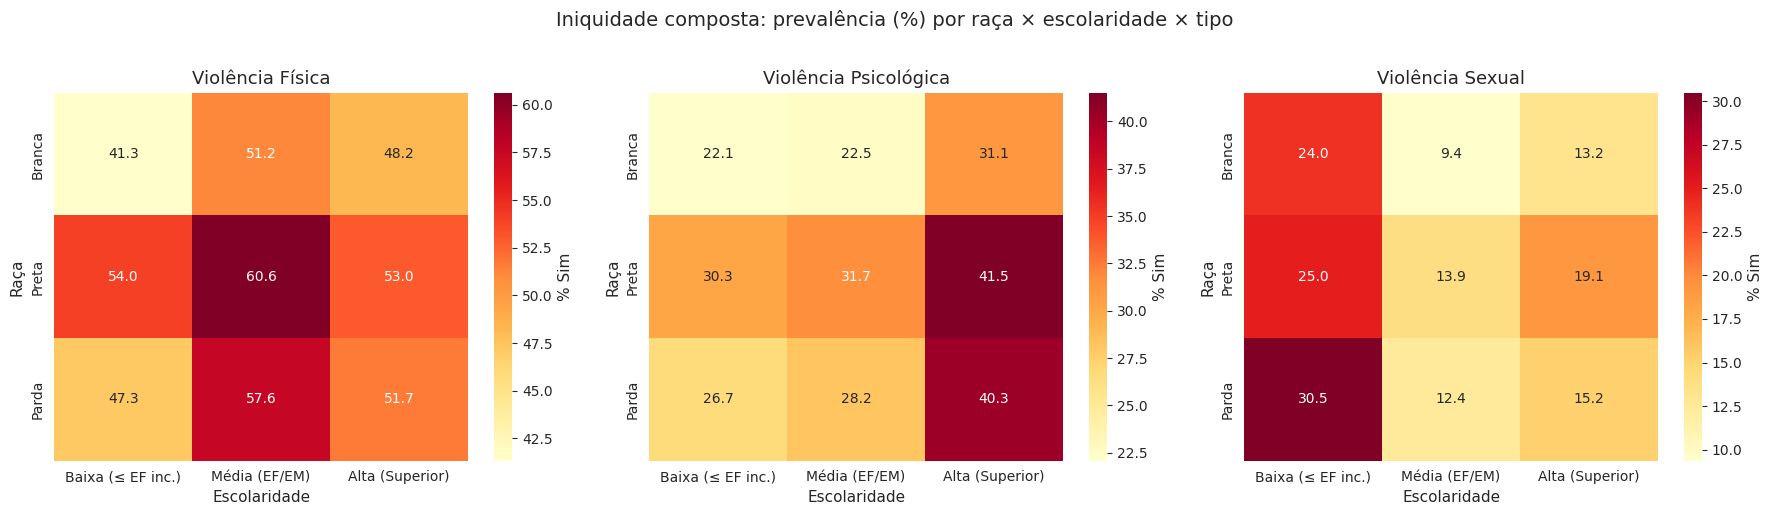


Tabela completa — prevalência (%) por raça × escolaridade:


--- Física ---
ESCOL_AGR  Alta (Superior)  Baixa (≤ EF inc.)  Média (EF/EM)
RACA                                                        
Branca                48.2               41.3           51.2
Parda                 51.7               47.3           57.6
Preta                 53.0               54.0           60.6

--- Psicológica ---
ESCOL_AGR  Alta (Superior)  Baixa (≤ EF inc.)  Média (EF/EM)
RACA                                                        
Branca                31.1               22.1           22.5
Parda                 40.3               26.7           28.2
Preta                 41.5               30.3           31.7

--- Sexual ---
ESCOL_AGR  Alta (Superior)  Baixa (≤ EF inc.)  Média (EF/EM)
RACA                                                        
Branca                13.2               24.0            9.4
Parda                 15.2               30.5           12.4
Preta                 19.1      

In [82]:
# ============================================================
# 3.2 — Iniquidade composta: raça × escolaridade × tipo
# ============================================================
# Agrupa escolaridade em 3 níveis para reduzir dimensão
def agrupar_escol(c):
    if pd.isna(c): return 'Não informado'
    c = str(c).zfill(2)
    if c in ('00', '01', '02', '03'): return 'Baixa (≤ EF inc.)'
    if c in ('04', '05', '06'):       return 'Média (EF/EM)'
    if c in ('07', '08'):              return 'Alta (Superior)'
    return 'Não informado'

df['ESCOL_AGR'] = df['CS_ESCOL_N'].apply(agrupar_escol)

# Filtra raças principais e escolaridades válidas
sub = df[
    df['RACA'].isin(['Branca', 'Preta', 'Parda']) &
    df['ESCOL_AGR'].isin(['Baixa (≤ EF inc.)', 'Média (EF/EM)', 'Alta (Superior)'])
].copy()

# Para cada combinação raça × escolaridade, calcula prevalência dos 3 tipos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, tipo, nome in zip(axes,
                            ['y_fisic', 'y_psico', 'y_sexu'],
                            ['Física', 'Psicológica', 'Sexual']):
    cruz = sub.groupby(['RACA', 'ESCOL_AGR'])[tipo].mean().unstack() * 100
    cruz = cruz.reindex(['Branca', 'Preta', 'Parda'])
    cruz = cruz[['Baixa (≤ EF inc.)', 'Média (EF/EM)', 'Alta (Superior)']]

    sns.heatmap(cruz, annot=True, fmt='.1f', cmap='YlOrRd',
                ax=ax, cbar_kws={'label': '% Sim'})
    ax.set_title(f'Violência {nome}')
    ax.set_xlabel('Escolaridade')
    ax.set_ylabel('Raça')

plt.suptitle('Iniquidade composta: prevalência (%) por raça × escolaridade × tipo',
              fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Tabela numérica
print('\nTabela completa — prevalência (%) por raça × escolaridade:\n')
for tipo, nome in [('y_fisic','Física'), ('y_psico','Psicológica'), ('y_sexu','Sexual')]:
    print(f'\n--- {nome} ---')
    cruz = sub.groupby(['RACA', 'ESCOL_AGR'])[tipo].mean().unstack() * 100
    print(cruz.round(1))

In [83]:
# ============================================================
# 5.2 — "Mulher típica" em 3 cenários extremos
# ============================================================
def perfil(sub, nome):
    print(f'\n{"="*60}')
    print(f'CENÁRIO: {nome}')
    print(f'{"="*60}')
    print(f'Total de casos:         {len(sub):,}')
    if len(sub) == 0:
        print('Sem casos para esse cenário.')
        return

    print(f'\n— Idade —')
    print(f'  Mediana:              {sub["IDADE"].median():.0f} anos')
    print(f'  Média:                {sub["IDADE"].mean():.1f} anos')
    print(f'  Faixa típica (Q1-Q3): {sub["IDADE"].quantile(0.25):.0f}-{sub["IDADE"].quantile(0.75):.0f}')

    print(f'\n— Raça/cor (top 3) —')
    raca_top = sub['RACA'].value_counts(normalize=True).head(3) * 100
    for r, p in raca_top.items():
        print(f'  {r:15s}: {p:.1f}%')

    print(f'\n— Escolaridade (top 3) —')
    esc_top = sub['ESCOL'].value_counts(normalize=True).head(3) * 100
    for e, p in esc_top.items():
        print(f'  {e:25s}: {p:.1f}%')

    print(f'\n— Reincidência (OUT_VEZES) —')
    rein = sub['OUT_VEZES'].map(MAP_SIM_NAO).value_counts(normalize=True) * 100
    for r, p in rein.items():
        print(f'  {r:15s}: {p:.1f}%')

    print(f'\n— Outros tipos coocorrentes —')
    for t, n in [('y_fisic','Física'), ('y_psico','Psicológica'), ('y_sexu','Sexual')]:
        prev = sub[t].mean() * 100
        print(f'  {n:13s}: {prev:.1f}% também sofreu este tipo')

# Cenário A — Violência física por parceiro em residência
cen_a = df[
    (df['y_fisic'] == 1) &
    (df['REL_AGRESSOR'].isin(['Parceiro atual', 'Ex-parceiro'])) &
    (df['LOCAL'] == 'Residência')
]
perfil(cen_a, 'A — Física por parceiro em residência')

# Cenário B — Violência sexual por desconhecido em via pública
cen_b = df[
    (df['y_sexu'] == 1) &
    (df['REL_AGRESSOR'] == 'Desconhecido') &
    (df['LOCAL'] == 'Via pública')
]
perfil(cen_b, 'B — Sexual por desconhecido em via pública')

# Cenário C — Violência psicológica com revitimização
cen_c = df[
    (df['y_psico'] == 1) &
    (df['OUT_VEZES'] == '1')
]
perfil(cen_c, 'C — Psicológica crônica (com revitimização)')


CENÁRIO: A — Física por parceiro em residência
Total de casos:         291,829

— Idade —
  Mediana:              32 anos
  Média:                34.0 anos
  Faixa típica (Q1-Q3): 25-41

— Raça/cor (top 3) —
  Parda          : 45.4%
  Branca         : 36.9%
  Preta          : 11.7%

— Escolaridade (top 3) —
  EM completo              : 25.0%
  Ignorado                 : 24.5%
  EM incompleto            : 11.1%

— Reincidência (OUT_VEZES) —
  Sim            : 62.6%
  Não            : 25.2%
  Ignorado       : 12.3%

— Outros tipos coocorrentes —
  Física       : 100.0% também sofreu este tipo
  Psicológica  : 42.0% também sofreu este tipo
  Sexual       : 4.6% também sofreu este tipo

CENÁRIO: B — Sexual por desconhecido em via pública
Total de casos:         15,324

— Idade —
  Mediana:              23 anos
  Média:                25.4 anos
  Faixa típica (Q1-Q3): 17-32

— Raça/cor (top 3) —
  Parda          : 46.0%
  Branca         : 35.5%
  Preta          : 13.7%

— Escolaridade (top